# Импорты

In [ ]:
!pip install plotly nbformat
!pip install pandas matplotlib seaborn
!pip install pandas matplotlib seaborn sentence-transformers
# !pip install tf-keras
!pip install lifelines
!pip install xgboost


import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
import ast
from datetime import datetime
import plotly.express as px
from sklearn.preprocessing import StandardScaler, OneHotEncoder, LabelEncoder
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.model_selection import train_test_split, cross_val_score
from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score, r2_score, mean_absolute_error, mean_squared_error
from sklearn.linear_model import LinearRegression, Ridge, Lasso
from sklearn.cluster import KMeans
from sklearn.decomposition import PCA
from lifelines import KaplanMeierFitter
from lifelines.statistics import logrank_test
from scipy.stats import chi2_contingency, pearsonr, spearmanr
from transformers import AutoTokenizer, AutoModel
import torch


warnings.filterwarnings('ignore')
sns.set_style("whitegrid")
sns.set_palette("husl")
plt.rcParams['figure.figsize'] = (12, 6)
plt.rcParams['figure.dpi'] = 100

# Загрузка данных

In [2]:
df = pd.read_csv("github_repositories_2025.csv")

df["license_spdx_id"] = df["license_spdx_id"].fillna("")
df["readme"] = df["readme"].fillna("")
df["owner_location"] = df["owner_location"].fillna("")


df["topics"] = df["topics"].apply(lambda x: ast.literal_eval(x) if isinstance(x, str) else x)
df["languages_map"] = df["languages_map"].apply(lambda x: ast.literal_eval(x) if isinstance(x, str) else x)
df["created_at"] = pd.to_datetime(df["created_at"])
df["pushed_at"] = pd.to_datetime(df["pushed_at"])


lang_df = pd.json_normalize(df["languages_map"]).fillna(0)
lang_df = lang_df.add_prefix("lang_")
df = pd.concat([df.drop(columns=["languages_map"]), lang_df], axis=1)


lang_cols = df.filter(like="lang_").columns
popular_counts = (df[lang_cols] > 0).sum().sort_values(ascending=False)
top_langs = popular_counts.head(10).index
df = pd.concat([df.drop(columns=lang_cols), df[top_langs]], axis=1)


def get_primary_language(row):
    if not top_langs.any():
        return "Unknown"
    best_lang = "Unknown"
    best_value = 0
    for col in top_langs:
        value = row[col]
        if pd.notna(value) and value > best_value:
            best_value = value
            best_lang = col.replace('lang_', '')
    return best_lang

df["primary_language"] = df.apply(get_primary_language, axis=1)


df["readme_length"] = df["readme"].str.len()
df["readme_has_code"] = df["readme"].str.contains("```", na=False).astype(int)
df["total_pr_count"] = df["open_pr_count"] + df["closed_pr_count"]
df["created_month"] = df["created_at"].dt.to_period("M").astype(str)
df["pushed_month"] = df["pushed_at"].dt.to_period("M").astype(str)
df["popularity"] = np.log1p(df["stargazers_count"])
df["repo_age_days"] = (pd.Timestamp.now(tz='UTC') - df["created_at"]).dt.days

print(f"Данные загружены: {len(df)} строк, {len(df.columns)} колонок")



github_id:
github_id
<class 'int'>    541
Name: count, dtype: int64

readme:
readme
<class 'str'>      540
<class 'float'>      1
Name: count, dtype: int64

releases_count:
releases_count
<class 'int'>    541
Name: count, dtype: int64

subscribers_count:
subscribers_count
<class 'int'>    541
Name: count, dtype: int64

stargazers_count:
stargazers_count
<class 'int'>    541
Name: count, dtype: int64

forks_count:
forks_count
<class 'int'>    541
Name: count, dtype: int64

created_at:
created_at
<class 'str'>    541
Name: count, dtype: int64

license_spdx_id:
license_spdx_id
<class 'str'>      467
<class 'float'>     74
Name: count, dtype: int64

topics:
topics
<class 'str'>    541
Name: count, dtype: int64

pushed_at:
pushed_at
<class 'str'>    541
Name: count, dtype: int64

languages_map:
languages_map
<class 'str'>    541
Name: count, dtype: int64

open_issues_count:
open_issues_count
<class 'int'>    541
Name: count, dtype: int64

closed_issues_count:
closed_issues_count
<class 'in

In [3]:
df.head()

In [9]:
print(popular_counts.head(20))

### Матрица корреляции

In [11]:
df_corr = df.select_dtypes(include=["number"]).drop(columns=["github_id"])
corr = df_corr.corr(numeric_only=True)

fig = px.imshow(
    corr,
    text_auto=True,          
    color_continuous_scale="Magma",
    zmin=-1,
    zmax=1,
    aspect="auto"
)

fig.update_layout(
    width=900,
    height=800
)

fig.show()
df.info()

C:\Users\Ирина\AppData\Local\Programs\Python\Python39\lib\site-packages\plotly\io\_renderers.py:51: UserWarning: Plotly version >= 6 requires Jupyter Notebook >= 7 but you have 6.5.4 installed.
 To upgrade Jupyter Notebook, please run `pip install notebook --upgrade`.
  warnings.warn(


### Кластеризация

In [16]:

try:
    print(f"Данные загружены: {len(df)} строк")
except:
    print("Сначала загрузите данные: df = pd.read_csv('github_repositories_2025.csv')")

model_name = "sentence-transformers/paraphrase-multilingual-MiniLM-L12-v2"

tokenizer = AutoTokenizer.from_pretrained(model_name)
model = AutoModel.from_pretrained(model_name)
model.eval()

print(f"Модель загружена: {model_name}")


def mean_pooling(model_output, attention_mask):
    token_embeddings = model_output[0]  
    input_mask_expanded = attention_mask.unsqueeze(-1).expand(token_embeddings.size()).float()
    return torch.sum(token_embeddings * input_mask_expanded, 1) / torch.clamp(input_mask_expanded.sum(1), min=1e-9)

def to_embedding(text):
    if not text or pd.isna(text):
        return None
    
    encoded_input = tokenizer(
        str(text), 
        padding=True, 
        truncation=True, 
        max_length=512, 
        return_tensors='pt'
    )
    
    with torch.no_grad():
        model_output = model(**encoded_input)
    
    embeddings = mean_pooling(model_output, encoded_input['attention_mask'])
    

    embeddings = torch.nn.functional.normalize(embeddings, p=2, dim=1)
    
    return embeddings[0].tolist()

def topics_to_embedding(topics):
    if not topics:
        return None
    if isinstance(topics, list):
        text = " ".join(topics)
    else:
        text = str(topics)
    return to_embedding(text)

print("\nГенерация эмбеддингов README")
df["readme_embedding"] = df["readme"].fillna("").apply(to_embedding)

print("Генерация эмбеддингов тем")
df["topics_embedding"] = df["topics"].apply(topics_to_embedding)

print(f"\nРезультат:")
print(f"  Эмбеддингов README: {df['readme_embedding'].notna().sum()}")
print(f"  Эмбеддингов тем: {df['topics_embedding'].notna().sum()}")


Данные загружены: 541 строк

Загрузка модели...



[notice] A new release of pip is available: 25.2 -> 26.0.1
[notice] To update, run: python.exe -m pip install --upgrade pip


tokenizer_config.json:   0%|          | 0.00/526 [00:00<?, ?B/s]

Xet Storage is enabled for this repo, but the 'hf_xet' package is not installed. Falling back to regular HTTP download. For better performance, install the package with: `pip install huggingface_hub[hf_xet]` or `pip install hf_xet`


tokenizer.json:   0%|          | 0.00/9.08M [00:00<?, ?B/s]

special_tokens_map.json:   0%|          | 0.00/239 [00:00<?, ?B/s]

config.json:   0%|          | 0.00/645 [00:00<?, ?B/s]

Xet Storage is enabled for this repo, but the 'hf_xet' package is not installed. Falling back to regular HTTP download. For better performance, install the package with: `pip install huggingface_hub[hf_xet]` or `pip install hf_xet`


model.safetensors:   0%|          | 0.00/471M [00:00<?, ?B/s]

Модель загружена: sentence-transformers/paraphrase-multilingual-MiniLM-L12-v2

Генерация эмбеддингов README...
Генерация эмбеддингов тем...

Результат:
  Эмбеддингов README: 540
  Эмбеддингов тем: 307


# Кластеризация

In [19]:
df_clean = df.drop(columns=["github_id"]).copy()
df_clean = df_clean.dropna(subset=["readme_embedding", "topics_embedding"]).copy()

readme_embeddings = np.vstack(df_clean["readme_embedding"].values)
topics_embeddings = np.vstack(df_clean["topics_embedding"].values)

numeric_cols = df_clean.select_dtypes(include=["number"]).columns.tolist()
X_num = df_clean[numeric_cols].values

X = np.hstack([X_num, readme_embeddings, topics_embeddings])

X[np.isinf(X)] = np.nan
mask = ~np.isnan(X).any(axis=1)

X = X[mask]
df_clean = df_clean.iloc[mask].copy()

scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

pca = PCA(n_components=3, svd_solver="full")
X_pca = pca.fit_transform(X_scaled)

df_clean["pc1"] = X_pca[:, 0]
df_clean["pc2"] = X_pca[:, 1]
df_clean["pc3"] = X_pca[:, 2]

kmeans = KMeans(n_clusters=5, random_state=42, n_init=10)
df_clean["cluster"] = kmeans.fit_predict(X_scaled).astype(str)


hover_cols = [
    "releases_count",
    "subscribers_count",
    "stargazers_count",
    "forks_count",
    "open_issues_count",
    "closed_issues_count",
    "open_pr_count",
    "closed_pr_count",
    "contributors_count",
    "commits_count",
    "owner_location",
    "license_spdx_id",
    "cluster"
]

fig = px.scatter_3d(
    df_clean,
    x="pc1",
    y="pc2",
    z="pc3",
    color="cluster",
    hover_name="full_name",
    hover_data=hover_cols,
    title="Кластеризация репозиториев"
)

fig.update_layout(
    width=1000,
    height=800
)

fig.write_html("clusters_3d.html")
print("График сохранён в файл 'clusters_3d.html'")

График сохранён в файл 'clusters_3d.html'
Откройте его в любом браузере


# Распределение

In [21]:
report_df = df.copy()

report_df["created_at"] = pd.to_datetime(
    report_df["created_at"], errors="coerce", utc=True
)
report_df["pushed_at"] = pd.to_datetime(
    report_df["pushed_at"], errors="coerce", utc=True
)

report_df["created_month"] = report_df["created_at"].dt.to_period("M").astype(str)
report_df["pushed_month"] = report_df["pushed_at"].dt.to_period("M").astype(str)

lang_cols = [c for c in report_df.columns if c.startswith("lang_")]


report_df["primary_language"] = report_df.apply(get_primary_language, axis=1)


location_top = (
    report_df["owner_location"]
    .fillna("Unknown")
    .astype(str)
    .value_counts()
    .head(20)
    .reset_index()
)

location_top.columns = ["location", "count"]

fig_map = px.scatter_geo(
    location_top,
    locations="location",
    locationmode="country names",
    size="count",
    color="count",
    hover_name="location",
    projection="natural earth",
    title="География владельцев репозиториев",
    color_continuous_scale="Blues", 
)

fig_map.update_layout(template="plotly_white", height=600)

fig_map.show()


license_top = report_df["license_spdx_id"].fillna("Unknown").value_counts().head(10)

fig_license = px.pie(
    names=license_top.index, values=license_top.values, hole=0.4, title="Доли лицензий"
)

fig_license.update_layout(template="plotly_white")
fig_license.show()


lang_top = report_df["primary_language"].value_counts().head(10)

fig_lang = px.pie(
    names=lang_top.index,
    values=lang_top.values,
    hole=0.4,
    title="Основной язык репозиториев",
)

fig_lang.update_layout(template="plotly_white")
fig_lang.show()

created_ts = report_df.groupby("created_month").size().reset_index(name="repos_created")

fig_created = px.line(
    created_ts,
    x="created_month",
    y="repos_created",
    markers=True,
    title="Создание репозиториев по месяцам",
)

fig_created.update_layout(template="plotly_white")
fig_created.show()

pushed_ts = report_df.groupby("pushed_month").size().reset_index(name="repos_pushed")

fig_pushed = px.line(
    pushed_ts,
    x="pushed_month",
    y="repos_pushed",
    markers=True,
    title="Активность push по месяцам",
)

fig_pushed.update_layout(template="plotly_white")
fig_pushed.show()

# Задача 1

АНАЛИЗ ЗАВИСИМОСТИ PR ОТ ДЛИНЫ README

Корреляция длины README с PR-метриками:
--------------------------------------------------

open_pr_count:
  Pearson:  r = 0.0179, p = 0.6779 (ns)
  Spearman: ρ = 0.1253, p = 0.0035 **

closed_pr_count:
  Pearson:  r = -0.0341, p = 0.4280 (ns)
  Spearman: ρ = 0.1459, p = 0.0007 ***

total_pr_count:
  Pearson:  r = -0.0311, p = 0.4697 (ns)
  Spearman: ρ = 0.1500, p = 0.0005 ***


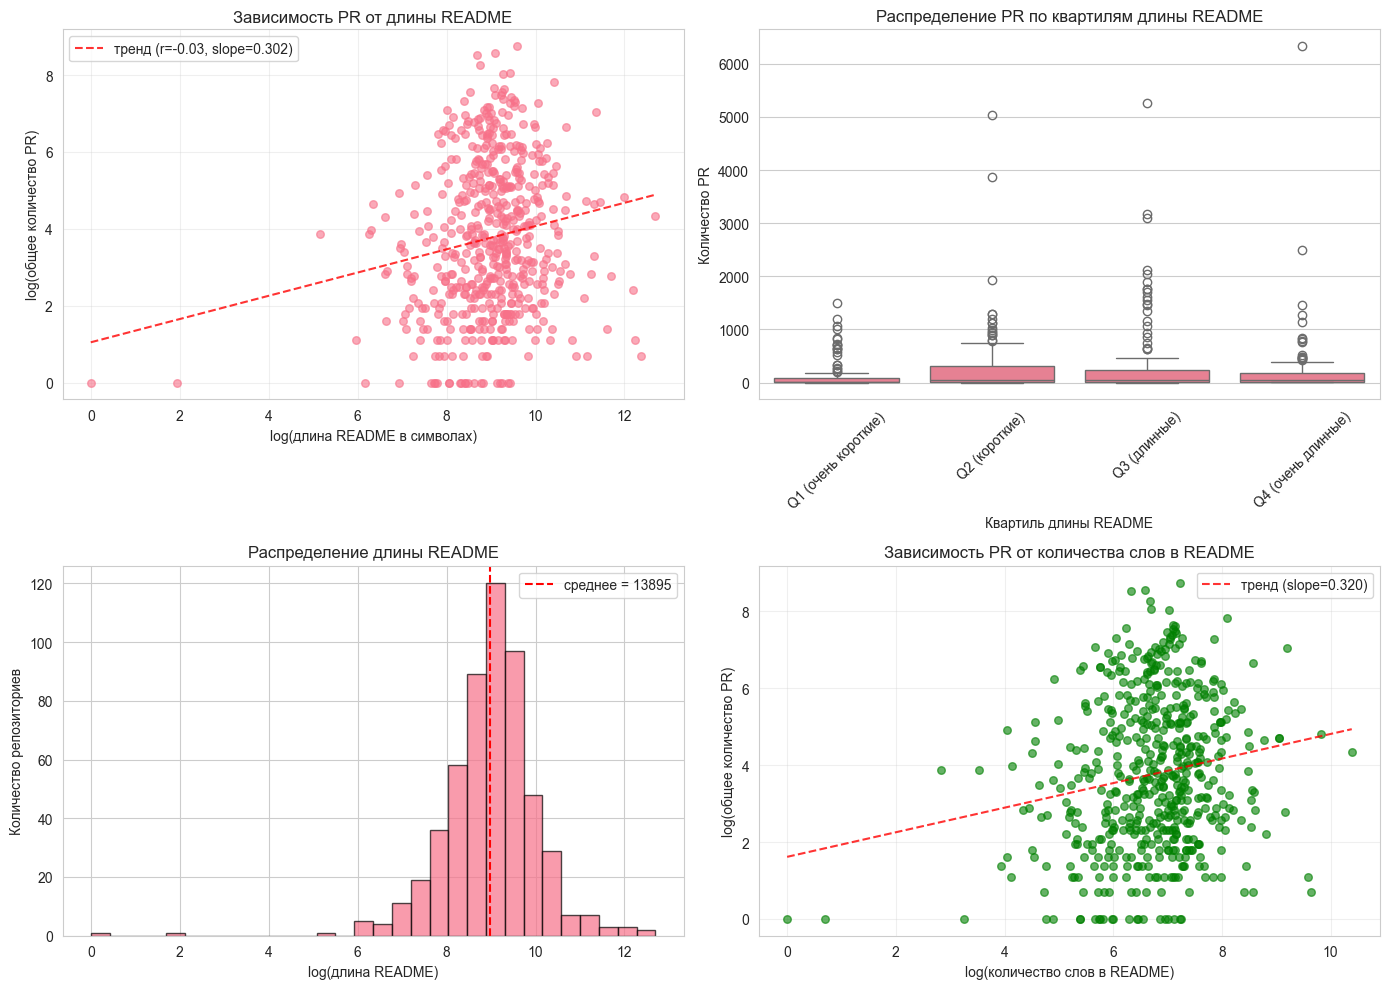


Статистика PR по квартилям длины README:
--------------------------------------------------
                     Кол-во репозиториев  Среднее PR  Медиана PR  \
length_quartile                                                    
Q1 (очень короткие)                  136      121.49        15.5   
Q2 (короткие)                        135      294.87        53.0   
Q3 (длинные)                         135      342.42        42.0   
Q4 (очень длинные)                   135      212.01        54.0   

                     Станд. отклонение  Максимум PR  
length_quartile                                      
Q1 (очень короткие)             262.04         1504  
Q2 (короткие)                   625.36         5033  
Q3 (длинные)                    733.91         5263  
Q4 (очень длинные)              618.79         6332  


In [22]:
print("АНАЛИЗ ЗАВИСИМОСТИ PR ОТ ДЛИНЫ README")

df_analysis = df.copy()
df_analysis["readme"] = df_analysis["readme"].fillna("")
df_analysis["readme_length_chars"] = df_analysis["readme"].str.len()
df_analysis["readme_length_words"] = df_analysis["readme"].str.split().str.len()
df_analysis["total_pr_count"] = df_analysis["open_pr_count"] + df_analysis["closed_pr_count"]

print("\nКорреляция длины README с PR-метриками:")

pr_metrics = ["open_pr_count", "closed_pr_count", "total_pr_count"]
correlation_results = {} 

for metric in pr_metrics:
    pearson_r, pearson_p = pearsonr(df_analysis["readme_length_chars"], df_analysis[metric])
    spearman_r, spearman_p = spearmanr(df_analysis["readme_length_chars"], df_analysis[metric])
    
    correlation_results[metric] = {"pearson_r": pearson_r, "spearman_r": spearman_r}
    
    print(f"\n{metric}:")
    print(f"  Pearson:  r = {pearson_r:.4f}, p = {pearson_p:.4f}")
    print(f"  Spearman: ρ = {spearman_r:.4f}, p = {spearman_p:.4f}")


fig, axes = plt.subplots(2, 2, figsize=(14, 10))

ax1 = axes[0, 0]
log_length = np.log1p(df_analysis["readme_length_chars"])
log_total_pr = np.log1p(df_analysis["total_pr_count"])

ax1.scatter(log_length, log_total_pr, alpha=0.6, s=30)

pearson_r_total = correlation_results["total_pr_count"]["pearson_r"]
z = np.polyfit(log_length, log_total_pr, 1)
p = np.poly1d(z)
x_trend = np.linspace(log_length.min(), log_length.max(), 100)
ax1.plot(x_trend, p(x_trend), "r--", alpha=0.8, 
         label=f'тренд (r={pearson_r_total:.2f}, slope={z[0]:.3f})')

ax1.set_xlabel("log(длина README в символах)")
ax1.set_ylabel("log(общее количество PR)")
ax1.set_title("Зависимость PR от длины README")
ax1.grid(True, alpha=0.3)
ax1.legend()

ax2 = axes[0, 1]
df_analysis["length_quartile"] = pd.qcut(df_analysis["readme_length_chars"], 
                                          q=4, 
                                          labels=["Q1 (очень короткие)", "Q2 (короткие)", 
                                                  "Q3 (длинные)", "Q4 (очень длинные)"])
sns.boxplot(data=df_analysis, x="length_quartile", y="total_pr_count", ax=ax2)
ax2.set_xlabel("Квартиль длины README")
ax2.set_ylabel("Количество PR")
ax2.set_title("Распределение PR по квартилям длины README")
ax2.tick_params(axis='x', rotation=45)

ax3 = axes[1, 0]
ax3.hist(log_length, bins=30, edgecolor='black', alpha=0.7)
ax3.axvline(log_length.mean(), color='red', linestyle='--', 
            label=f'среднее = {df_analysis["readme_length_chars"].mean():.0f}')
ax3.set_xlabel("log(длина README)")
ax3.set_ylabel("Количество репозиториев")
ax3.set_title("Распределение длины README")
ax3.legend()
ax4 = axes[1, 1]
log_words = np.log1p(df_analysis["readme_length_words"])
ax4.scatter(log_words, log_total_pr, alpha=0.6, s=30, c='green')

z_words = np.polyfit(log_words, log_total_pr, 1)
p_words = np.poly1d(z_words)
x_trend_words = np.linspace(log_words.min(), log_words.max(), 100)
ax4.plot(x_trend_words, p_words(x_trend_words), "r--", alpha=0.8,
         label=f'тренд (slope={z_words[0]:.3f})')

ax4.set_xlabel("log(количество слов в README)")
ax4.set_ylabel("log(общее количество PR)")
ax4.set_title("Зависимость PR от количества слов в README")
ax4.grid(True, alpha=0.3)
ax4.legend()

plt.tight_layout()
plt.show()


print("\nСтатистика PR по квартилям длины README:")
quartile_stats = df_analysis.groupby("length_quartile")["total_pr_count"].agg([
    ("Кол-во репозиториев", "count"),
    ("Среднее PR", "mean"),
    ("Медиана PR", "median"),
    ("Станд. отклонение", "std"),
    ("Максимум PR", "max")
])
print(quartile_stats.round(2))


# Задача 2

ЗАДАЧА 2: РАСПРЕДЕЛЕНИЯ РЕПОЗИТОРИЕВ

1. ОСНОВНОЙ ЯЗЫК РАЗРАБОТКИ
Найдено языковых колонок: 10
Уникальных языков: 11
Примеры: {'Python': 214, 'TypeScript': 133, 'Unknown': 67, 'JavaScript': 33, 'Shell': 27}

Топ-10 языков программирования:
--------------------------------------------------
 1. Python               214 репозиториев (39.6%)
 2. TypeScript           133 репозиториев (24.6%)
 3. Unknown               67 репозиториев (12.4%)
 4. JavaScript            33 репозиториев (6.1%)
 5. Shell                 27 репозиториев (5.0%)
 6. Go                    24 репозиториев (4.4%)
 7. C++                   24 репозиториев (4.4%)
 8. HTML                   9 репозиториев (1.7%)
 9. CSS                    4 репозиториев (0.7%)
10. Dockerfile             3 репозиториев (0.6%)


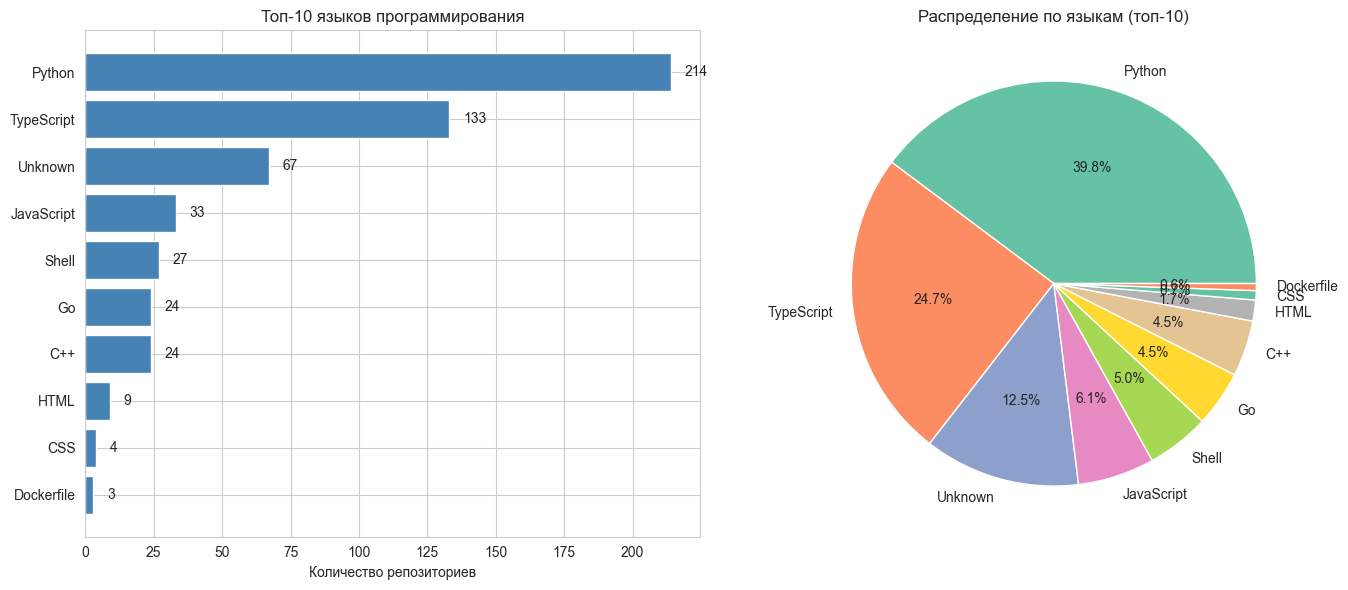


Топ-10 лицензий:
--------------------------------------------------
 1. MIT                  206 репозиториев (38.1%)
 2. Apache-2.0           126 репозиториев (23.3%)
 3.                       74 репозиториев (13.7%)
 4. NOASSERTION           59 репозиториев (10.9%)
 5. GPL-3.0               34 репозиториев (6.3%)
 6. AGPL-3.0              33 репозиториев (6.1%)
 7. GPL-2.0                2 репозиториев (0.4%)
 8. CC0-1.0                2 репозиториев (0.4%)
 9. MPL-2.0                1 репозиториев (0.2%)
10. BSD-3-Clause           1 репозиториев (0.2%)


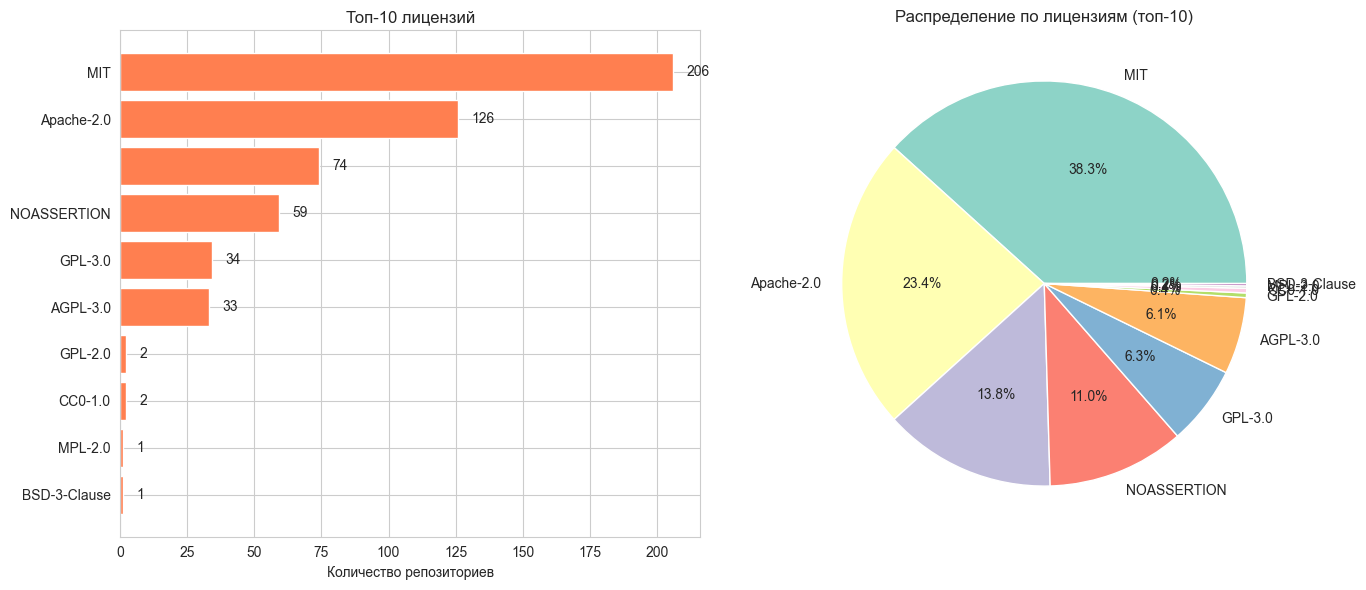

 Всего репозиториев: 541
Языки:
   - Уникальных языков: 11
   - Самый популярный: Python (214 реп.)
Лицензии:
   - Уникальных лицензий: 13
   - Самая популярная: MIT (206 реп.)


In [25]:
print(" РАСПРЕДЕЛЕНИЯ РЕПОЗИТОРИЕВ")


df_analysis = df.copy()
df_analysis["owner_location"] = df_analysis["owner_location"].fillna("Unknown")
df_analysis["license_spdx_id"] = df_analysis["license_spdx_id"].fillna("Unknown")



print("Основной язык разработки")
lang_cols = [c for c in df_analysis.columns if c.startswith('lang_')]
print(f"Найдено языковых колонок: {len(lang_cols)}")

df_analysis["primary_language"] = df_analysis.apply(get_primary_language, axis=1)

print(f"Уникальных языков: {df_analysis['primary_language'].nunique()}")
print(f"Примеры: {df_analysis['primary_language'].value_counts().head(5).to_dict()}")


lang_counts = df_analysis["primary_language"].value_counts()
lang_top10 = lang_counts.head(10)

print("\nТоп-10 языков программирования:")
print("-" * 50)
for i, (lang, count) in enumerate(lang_top10.items(), 1):
    pct = count / len(df_analysis) * 100
    print(f"{i:2d}. {lang:<20} {count:3d} репозиториев ({pct:.1f}%)")


fig, axes = plt.subplots(1, 2, figsize=(14, 6))


ax1 = axes[0]
bars = ax1.barh(range(len(lang_top10)), lang_top10.values, color='steelblue')
ax1.set_yticks(range(len(lang_top10)))
ax1.set_yticklabels(lang_top10.index)
ax1.set_xlabel("Количество репозиториев")
ax1.set_title("Топ-10 языков программирования")
ax1.invert_yaxis()

for i, (bar, count) in enumerate(zip(bars, lang_top10.values)):
    ax1.text(bar.get_width() + 5, bar.get_y() + bar.get_height()/2, 
             str(count), va='center', fontsize=10)


ax2 = axes[1]
colors = sns.color_palette("Set2", len(lang_top10))
ax2.pie(lang_top10.values, labels=lang_top10.index, autopct='%1.1f%%', colors=colors)
ax2.set_title("Распределение по языкам (топ-10)")

plt.tight_layout()
plt.show()

license_counts = df_analysis["license_spdx_id"].value_counts()
license_top10 = license_counts.head(10)

print("\nТоп-10 лицензий:")
print("-" * 50)
for i, (license, count) in enumerate(license_top10.items(), 1):
    pct = count / len(df_analysis) * 100
    print(f"{i:2d}. {license:<20} {count:3d} репозиториев ({pct:.1f}%)")

fig, axes = plt.subplots(1, 2, figsize=(14, 6))

ax1 = axes[0]
bars = ax1.barh(range(len(license_top10)), license_top10.values, color='coral')
ax1.set_yticks(range(len(license_top10)))
ax1.set_yticklabels(license_top10.index)
ax1.set_xlabel("Количество репозиториев")
ax1.set_title("Топ-10 лицензий")
ax1.invert_yaxis()

for i, (bar, count) in enumerate(zip(bars, license_top10.values)):
    ax1.text(bar.get_width() + 5, bar.get_y() + bar.get_height()/2, 
             str(count), va='center', fontsize=10)

ax2 = axes[1]
colors = sns.color_palette("Set3", len(license_top10))
ax2.pie(license_top10.values, labels=license_top10.index, autopct='%1.1f%%', colors=colors)
ax2.set_title("Распределение по лицензиям (топ-10)")

plt.tight_layout()
plt.show()



print(f" Всего репозиториев: {len(df_analysis)}")
print(f"Языки:")
print(f"   - Уникальных языков: {df_analysis['primary_language'].nunique()}")
print(f"   - Самый популярный: {lang_top10.index[0]} ({lang_top10.values[0]} реп.)")
print(f"Лицензии:")
print(f"   - Уникальных лицензий: {df_analysis['license_spdx_id'].nunique()}")
print(f"   - Самая популярная: {license_top10.index[0]} ({license_top10.values[0]} реп.)")



# Задача 3

ЗАДАЧА 3: ПРЕДСКАЗАНИЕ ПОПУЛЯРНОСТИ (ЛИНЕЙНАЯ РЕГРЕССИЯ)

Целевая переменная: stargazers_count (звёзды)
   Медиана: 2119
   После log1p: среднее = 7.89

Признаков для моделирования:
   Числовых: 12
   Категориальных: 1 (primary_language)
   Всего: 13

Размер выборки: 541 репозиториев
   Обучающая: 432 репозиториев
   Тестовая: 109 репозиториев

Результаты моделей:
   LinearRegression   R² = 0.0310, MAE = 0.6466
   Ridge              R² = 0.0390, MAE = 0.6428
   Lasso              R² = 0.1133, MAE = 0.6079

Ridge (кросс-валидация 5-fold):
   Средний R² = -4.0359 (+/- 8.0278)

Топ-10 наиболее важных признаков:
   + open_issues_count                       : 0.5479
   - closed_issues_count                     : -0.3985
   - primary_language_Shell                  : -0.3972
   - primary_language_C++                    : -0.2988
   + primary_language_JavaScript             : 0.2840
   + open_pr_count                           : 0.1825
   + primary_language_Unknown                : 0.1502
   

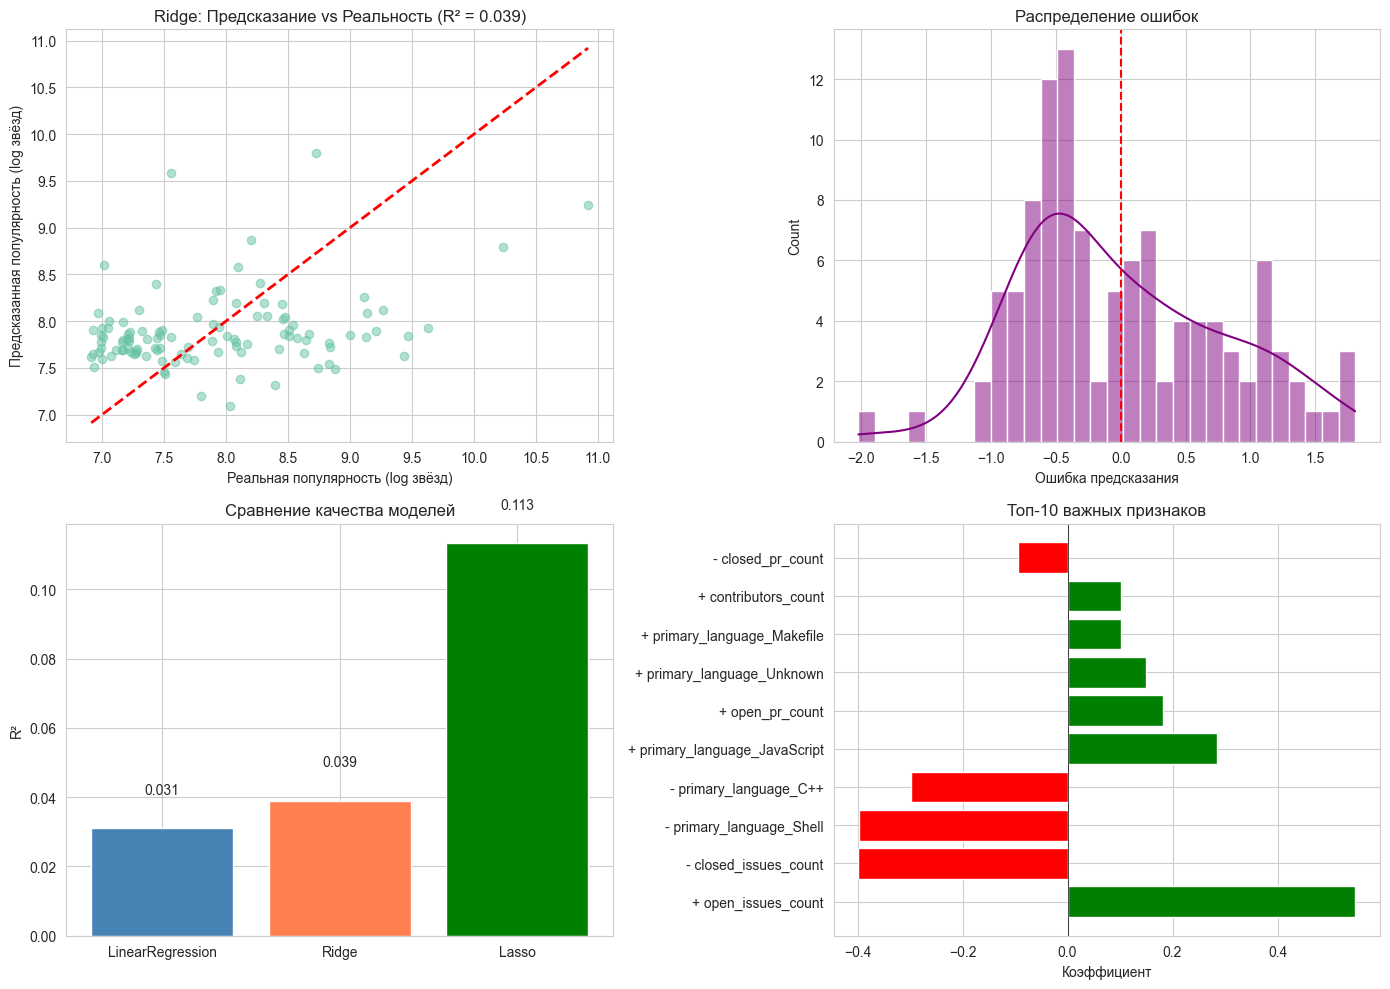


Лучшая модель: Lasso
   R² = 0.1133 (модель объясняет 11.3% дисперсии)
   MAE = 0.6079

Самые важные признаки для предсказания популярности:
    open_issues_count: увеличивает популярность (коэф. 0.5479)
    closed_issues_count: уменьшает популярность (коэф. -0.3985)
    primary_language_Shell: уменьшает популярность (коэф. -0.3972)
    primary_language_C++: уменьшает популярность (коэф. -0.2988)
    primary_language_JavaScript: увеличивает популярность (коэф. 0.2840)


In [27]:
print("ПРЕДСКАЗАНИЕ ПОПУЛЯРНОСТИ (ЛИНЕЙНАЯ РЕГРЕССИЯ)")

df_model = df.copy()

df_model["readme"] = df_model["readme"].fillna("")
df_model["license_spdx_id"] = df_model["license_spdx_id"].fillna("Unknown")
df_model["owner_location"] = df_model["owner_location"].fillna("Unknown")


df_model["popularity"] = np.log1p(df_model["stargazers_count"])

print(f"\nЦелевая переменная: stargazers_count (звёзды)")
print(f"   Медиана: {df_model['stargazers_count'].median():.0f}")
print(f"   После log1p: среднее = {df_model['popularity'].mean():.2f}")


feature_cols = [
    "releases_count",
    "open_issues_count", 
    "closed_issues_count",
    "open_pr_count",
    "closed_pr_count",
    "contributors_count",
    "commits_count"
]


df_model["readme_length"] = df_model["readme"].str.len()
df_model["readme_has_code"] = df_model["readme"].str.contains("```", na=False).astype(int)
feature_cols.extend(["readme_length", "readme_has_code"])


df_model["created_at"] = pd.to_datetime(df_model["created_at"], utc=True)
df_model["repo_age_days"] = (pd.Timestamp.now(tz='UTC') - df_model["created_at"]).dt.days
feature_cols.append("repo_age_days")


if "lang_Dockerfile" in df_model.columns:
    df_model["has_dockerfile"] = (df_model["lang_Dockerfile"] > 0).astype(int)
else:
    df_model["has_dockerfile"] = 0

df_model["has_github_actions"] = df_model["readme"].str.contains("actions|workflows", case=False, na=False).astype(int)
feature_cols.extend(["has_dockerfile", "has_github_actions"])


lang_columns = [col for col in df_model.columns if col.startswith('lang_')]


df_model["primary_language"] = df_model.apply(get_primary_language, axis=1)

print(f"\nПризнаков для моделирования:")
print(f"   Числовых: {len(feature_cols)}")
print(f"   Категориальных: 1 (primary_language)")
print(f"   Всего: {len(feature_cols) + 1}")
#-------------------------------------------------
X = df_model[feature_cols + ["primary_language"]].copy()
y = df_model["popularity"].copy()

df_model_clean = X.dropna()
y = y.loc[df_model_clean.index]
X = df_model_clean

print(f"\nРазмер выборки: {len(X)} репозиториев")

# ---------------------------------------------------
numeric_features = feature_cols
categorical_features = ["primary_language"]

preprocessor = ColumnTransformer([
    ("num", StandardScaler(), numeric_features),
    ("cat", OneHotEncoder(handle_unknown="ignore", sparse_output=False), categorical_features)
])

#-----------------------------------------------------------------
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

print(f"   Обучающая: {len(X_train)} репозиториев")
print(f"   Тестовая: {len(X_test)} репозиториев")

# ----------------------------------------------------------
results = []

lr_pipeline = Pipeline([
    ("preprocessor", preprocessor),
    ("regressor", LinearRegression())
])
lr_pipeline.fit(X_train, y_train)
y_pred_lr = lr_pipeline.predict(X_test)
r2_lr = r2_score(y_test, y_pred_lr)
mae_lr = mean_absolute_error(y_test, y_pred_lr)
results.append({"model": "LinearRegression", "r2": r2_lr, "mae": mae_lr})


ridge_pipeline = Pipeline([
    ("preprocessor", preprocessor),
    ("regressor", Ridge(alpha=1.0))
])
ridge_pipeline.fit(X_train, y_train)
y_pred_ridge = ridge_pipeline.predict(X_test)
r2_ridge = r2_score(y_test, y_pred_ridge)
mae_ridge = mean_absolute_error(y_test, y_pred_ridge)
results.append({"model": "Ridge", "r2": r2_ridge, "mae": mae_ridge})


lasso_pipeline = Pipeline([
    ("preprocessor", preprocessor),
    ("regressor", Lasso(alpha=0.01))
])
lasso_pipeline.fit(X_train, y_train)
y_pred_lasso = lasso_pipeline.predict(X_test)
r2_lasso = r2_score(y_test, y_pred_lasso)
mae_lasso = mean_absolute_error(y_test, y_pred_lasso)
results.append({"model": "Lasso", "r2": r2_lasso, "mae": mae_lasso})

print("\nРезультаты моделей:")

for r in results:
    print(f"   {r['model']:18} R² = {r['r2']:.4f}, MAE = {r['mae']:.4f}")


cv_scores = cross_val_score(ridge_pipeline, X, y, cv=5, scoring='r2')
print(f"\nRidge (кросс-валидация 5-fold):")
print(f"   Средний R² = {cv_scores.mean():.4f} (+/- {cv_scores.std():.4f})")

#---------------------------------------------------------

preprocessor.fit(X)
feature_names = numeric_features + list(preprocessor.named_transformers_["cat"].get_feature_names_out(categorical_features))

coefficients = ridge_pipeline.named_steps["regressor"].coef_
coef_df = pd.DataFrame({"feature": feature_names, "coefficient": coefficients})
coef_df["abs_coef"] = coef_df["coefficient"].abs()
coef_df = coef_df.sort_values("abs_coef", ascending=False)

print("\nТоп-10 наиболее важных признаков:")
for i, row in coef_df.head(10).iterrows():
    sign = "+" if row["coefficient"] > 0 else "-"
    print(f"   {sign} {row['feature'][:40]:<40}: {row['coefficient']:.4f}")

#-----------------------------------------------------

fig, axes = plt.subplots(2, 2, figsize=(14, 10))


ax1 = axes[0, 0]
ax1.scatter(y_test, y_pred_ridge, alpha=0.5)
ax1.plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], 'r--', lw=2)
ax1.set_xlabel("Реальная популярность (log звёзд)")
ax1.set_ylabel("Предсказанная популярность (log звёзд)")
ax1.set_title(f"Ridge: Предсказание vs Реальность (R² = {r2_ridge:.3f})")


ax2 = axes[0, 1]
errors = y_test - y_pred_ridge
sns.histplot(errors, bins=30, kde=True, ax=ax2, color='purple')
ax2.axvline(0, color='red', linestyle='--')
ax2.set_xlabel("Ошибка предсказания")
ax2.set_title("Распределение ошибок")


ax3 = axes[1, 0]
models_names = [r["model"] for r in results]
r2_scores = [r["r2"] for r in results]
bars = ax3.bar(models_names, r2_scores, color=['steelblue', 'coral', 'green'])
ax3.axhline(y=0, color='black', linestyle='-', linewidth=0.5)
ax3.set_ylabel("R²")
ax3.set_title("Сравнение качества моделей")
for bar, score in zip(bars, r2_scores):
    ax3.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.01, 
             f"{score:.3f}", ha='center', fontsize=10)


ax4 = axes[1, 1]
top_features = coef_df.head(10)
colors = ['green' if c > 0 else 'red' for c in top_features["coefficient"]]
bars = ax4.barh(range(len(top_features)), top_features["coefficient"], color=colors)
ax4.set_yticks(range(len(top_features)))
ax4.set_yticklabels([f"{'+' if c>0 else '-'} {f[:30]}" for f, c in zip(top_features["feature"], top_features["coefficient"])])
ax4.set_xlabel("Коэффициент")
ax4.set_title("Топ-10 важных признаков")
ax4.axvline(x=0, color='black', linestyle='-', linewidth=0.5)

plt.tight_layout()
plt.show()

#--------------------------------------------

best_model = max(results, key=lambda x: x["r2"])
print(f"\nЛучшая модель: {best_model['model']}")
print(f"   R² = {best_model['r2']:.4f} (модель объясняет {best_model['r2']*100:.1f}% дисперсии)")
print(f"   MAE = {best_model['mae']:.4f}")

print(f"\nСамые важные признаки для предсказания популярности:")
for _, row in coef_df.head(5).iterrows():
    impact = "увеличивает" if row["coefficient"] > 0 else "уменьшает"
    print(f"    {row['feature']}: {impact} популярность (коэф. {row['coefficient']:.4f})")

# Задача 4


Распределение лицензий:
  MIT                       206 (38.1%)
  Apache-2.0                126 (23.3%)
  "" (пустая)                74 (13.7%)
  NOASSERTION                59 (10.9%)
  GPL-3.0                    34 (6.3%)
  AGPL-3.0                   33 (6.1%)
  GPL-2.0                     2 (0.4%)
  CC0-1.0                     2 (0.4%)
  MPL-2.0                     1 (0.2%)
  BSD-3-Clause                1 (0.2%)
Для классификации оставляем: ['MIT', 'Apache-2.0', '(пустая)', 'NOASSERTION', 'GPL-3.0']
Репозиториев после фильтрации: 499
Классы: {'(пустая)': 0, 'Apache-2.0': 1, 'GPL-3.0': 2, 'MIT': 3, 'NOASSERTION': 4}

Признаки:
   Числовых: 13
   Категориальных: 1
Размер выборки после очистки: 499

Размеры выборок:
   Обучающая: 399
   Тестовая: 100


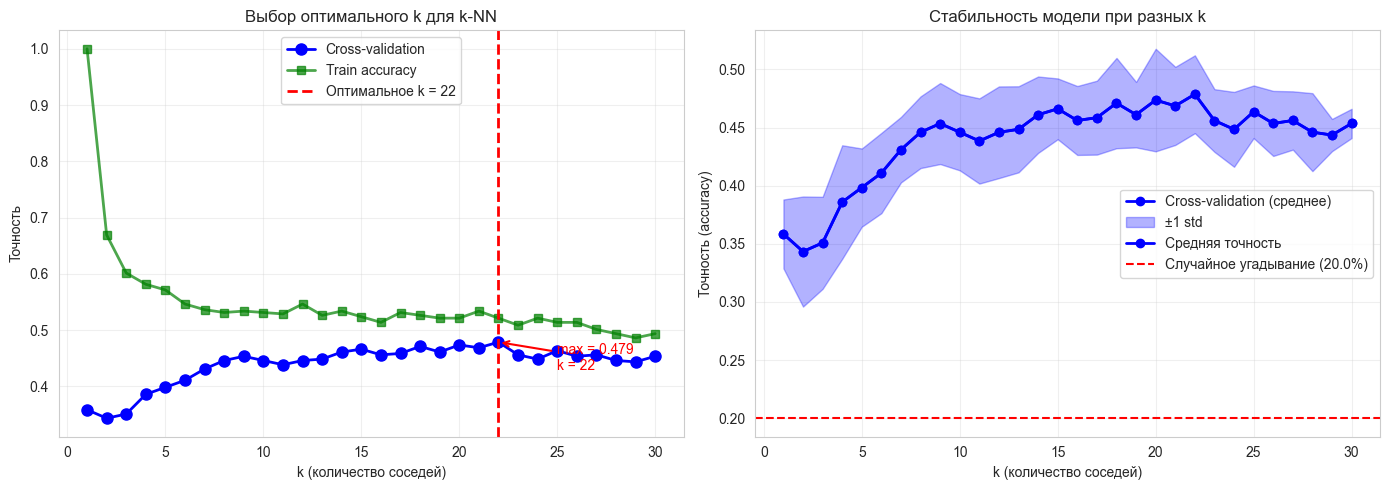


Оптимальное k = 22 (точность = 0.4787)

Точность на тестовой выборке: 0.3700 (37.0%)

Отчёт по классификации:
              precision    recall  f1-score   support

    (пустая)       0.23      0.20      0.21        15
  Apache-2.0       0.35      0.32      0.33        25
     GPL-3.0       0.00      0.00      0.00         7
         MIT       0.41      0.63      0.50        41
 NOASSERTION       0.00      0.00      0.00        12

    accuracy                           0.37       100
   macro avg       0.20      0.23      0.21       100
weighted avg       0.29      0.37      0.32       100



<Figure size 1200x500 with 0 Axes>

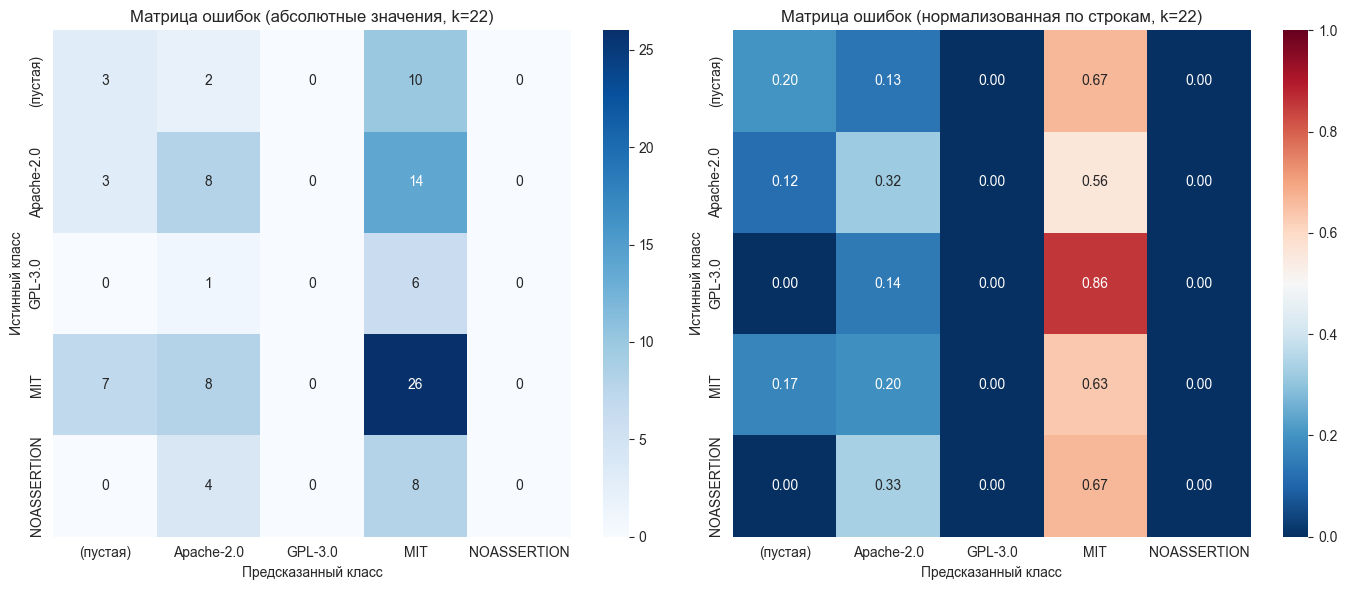

  k = 22 (оптимальный): точность = 0.3700
  k = 5 (по умолчанию):     точность = 0.4200
  Улучшение: -0.0500
АНАЛИЗ ОШИБОК
Всего ошибок: 63 из 100 (63.0%)

Точность по каждому классу:
  (пустая)            : 0.2000 (15 примеров)
  Apache-2.0          : 0.3200 (25 примеров)
  GPL-3.0             : 0.0000 (7 примеров)
  MIT                 : 0.6341 (41 примеров)
  NOASSERTION         : 0.0000 (12 примеров)

Наиболее частые ошибки (какие классы путают):
  Apache-2.0 → MIT: 14 раз
  (пустая) → MIT: 10 раз
  MIT → Apache-2.0: 8 раз
  NOASSERTION → MIT: 8 раз
  MIT → (пустая): 7 раз

Лучшая точность: 0.3700 (37.0%)
Оптимальное количество соседей k = 22
Модель правильно предсказывает лицензию в 37.0% случаев
Это значительно лучше случайного угадывания (20.0%)
Самые узнаваемые лицензии: MIT, Apache-2.0

Модель показывает низкое качество, возможно, нужны дополнительные признаки


In [39]:
plt.rcParams['figure.figsize'] = (16, 10)
plt.rcParams['figure.dpi'] = 100

df_class = df.copy()


df_class["readme"] = df_class["readme"].fillna("")
df_class["license_spdx_id"] = df_class["license_spdx_id"].fillna("")
df_class["owner_location"] = df_class["owner_location"].fillna("Unknown")

license_counts = df_class["license_spdx_id"].value_counts()
print("\nРаспределение лицензий:")

for lic, count in license_counts.head(10).items():
    lic_name = '"" (пустая)' if lic == '' else lic
    print(f"  {lic_name:<25} {count:3d} ({count/len(df_class)*100:.1f}%)")


top_licenses = license_counts.head(5).index.tolist()
print(f"Для классификации оставляем: {['(пустая)' if l=='' else l for l in top_licenses]}")

df_class_filtered = df_class[df_class["license_spdx_id"].isin(top_licenses)].copy()
print(f"Репозиториев после фильтрации: {len(df_class_filtered)}")

le = LabelEncoder()
y = le.fit_transform(df_class_filtered["license_spdx_id"])
print(f"Классы: {dict(zip([('(пустая)' if l=='' else l) for l in le.classes_], range(len(le.classes_))))}")

numeric_features = [
    "releases_count",
    "subscribers_count", 
    "stargazers_count",
    "forks_count",
    "open_issues_count",
    "closed_issues_count",
    "open_pr_count",
    "closed_pr_count",
    "contributors_count",
    "commits_count"
]

df_class_filtered["readme_length"] = df_class_filtered["readme"].str.len()
df_class_filtered["readme_has_code"] = df_class_filtered["readme"].str.contains("```", na=False).astype(int)
numeric_features.extend(["readme_length", "readme_has_code"])

df_class_filtered["created_at"] = pd.to_datetime(df_class_filtered["created_at"], utc=True)
df_class_filtered["repo_age_days"] = (pd.Timestamp.now(tz='UTC') - df_class_filtered["created_at"]).dt.days
numeric_features.append("repo_age_days")


lang_cols = [c for c in df_class_filtered.columns if c.startswith('lang_')]

df_class_filtered["primary_language"] = df_class_filtered.apply(get_primary_language, axis=1)
categorical_features = ["primary_language"]

print(f"\nПризнаки:")
print(f"   Числовых: {len(numeric_features)}")
print(f"   Категориальных: {len(categorical_features)}")

X = df_class_filtered[numeric_features + categorical_features].copy()
y = y.copy()

mask = ~X.isna().any(axis=1)
X = X[mask]
y = y[mask]

print(f"Размер выборки после очистки: {len(X)}")


preprocessor = ColumnTransformer([
    ("num", StandardScaler(), numeric_features),
    ("cat", OneHotEncoder(handle_unknown="ignore", sparse_output=False), categorical_features)
])


X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)

print(f"\nРазмеры выборок:")
print(f"   Обучающая: {len(X_train)}")
print(f"   Тестовая: {len(X_test)}")


k_values = range(1, 31)
cv_scores = []
train_scores = []

for k in k_values:
    knn = Pipeline([
        ("preprocessor", preprocessor),
        ("classifier", KNeighborsClassifier(n_neighbors=k))
    ])

    scores = cross_val_score(knn, X_train, y_train, cv=5, scoring='accuracy')
    cv_scores.append(scores.mean())
    

    knn.fit(X_train, y_train)
    train_acc = knn.score(X_train, y_train)
    train_scores.append(train_acc)

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

ax1 = axes[0]
ax1.plot(k_values, cv_scores, 'bo-', linewidth=2, markersize=8, label='Cross-validation')
ax1.plot(k_values, train_scores, 'gs-', linewidth=2, markersize=6, alpha=0.7, label='Train accuracy')
ax1.axvline(x=cv_scores.index(max(cv_scores)) + 1, color='r', linestyle='--', 
            linewidth=2, label=f"Оптимальное k = {cv_scores.index(max(cv_scores)) + 1}")
ax1.set_xlabel("k (количество соседей)")
ax1.set_ylabel("Точность")
ax1.set_title("Выбор оптимального k для k-NN")
ax1.legend()
ax1.grid(True, alpha=0.3)


best_k = cv_scores.index(max(cv_scores)) + 1
best_score = max(cv_scores)
ax1.annotate(f'max = {best_score:.3f}\nk = {best_k}', 
             xy=(best_k, best_score), 
             xytext=(best_k + 3, best_score - 0.05),
             arrowprops=dict(arrowstyle='->', color='red', lw=1.5),
             fontsize=10, color='red')


ax2 = axes[1]
ax2.plot(k_values, cv_scores, 'bo-', linewidth=2, markersize=6, label='Cross-validation (среднее)')


knn_temp = KNeighborsClassifier()
all_scores = []
for k in k_values:
    knn = Pipeline([("preprocessor", preprocessor), ("classifier", KNeighborsClassifier(n_neighbors=k))])
    scores = cross_val_score(knn, X_train, y_train, cv=5, scoring='accuracy')
    all_scores.append(scores)

scores_array = np.array(all_scores)
mean_scores = scores_array.mean(axis=1)
std_scores = scores_array.std(axis=1)

ax2.fill_between(k_values, mean_scores - std_scores, mean_scores + std_scores, 
                  alpha=0.3, color='blue', label='±1 std')
ax2.plot(k_values, mean_scores, 'bo-', linewidth=2, markersize=6, label='Средняя точность')
ax2.axhline(y=1/len(le.classes_), color='r', linestyle='--', 
            label=f"Случайное угадывание ({1/len(le.classes_)*100:.1f}%)")
ax2.set_xlabel("k (количество соседей)")
ax2.set_ylabel("Точность (accuracy)")
ax2.set_title("Стабильность модели при разных k")
ax2.legend()
ax2.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

print(f"\nОптимальное k = {best_k} (точность = {best_score:.4f})")

knn_best = Pipeline([
    ("preprocessor", preprocessor),
    ("classifier", KNeighborsClassifier(n_neighbors=best_k))
])

knn_best.fit(X_train, y_train)
y_pred = knn_best.predict(X_test)


accuracy = accuracy_score(y_test, y_pred)
print(f"\nТочность на тестовой выборке: {accuracy:.4f} ({accuracy*100:.1f}%)")

print("\nОтчёт по классификации:")
print(classification_report(y_test, y_pred, target_names=[('(пустая)' if l=='' else l) for l in le.classes_]))

plt.figure(figsize=(12, 5))
cm = confusion_matrix(y_test, y_pred)
cm_normalized = cm.astype('float') / cm.sum(axis=1)[:, np.newaxis]


fig, axes = plt.subplots(1, 2, figsize=(14, 6))


ax1 = axes[0]
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', 
            xticklabels=[('(пустая)' if l=='' else l) for l in le.classes_],
            yticklabels=[('(пустая)' if l=='' else l) for l in le.classes_],
            ax=ax1)
ax1.set_xlabel("Предсказанный класс")
ax1.set_ylabel("Истинный класс")
ax1.set_title(f"Матрица ошибок (абсолютные значения, k={best_k})")


ax2 = axes[1]
sns.heatmap(cm_normalized, annot=True, fmt='.2f', cmap='RdBu_r', vmin=0, vmax=1,
            xticklabels=[('(пустая)' if l=='' else l) for l in le.classes_],
            yticklabels=[('(пустая)' if l=='' else l) for l in le.classes_],
            ax=ax2)
ax2.set_xlabel("Предсказанный класс")
ax2.set_ylabel("Истинный класс")
ax2.set_title(f"Матрица ошибок (нормализованная по строкам, k={best_k})")

plt.tight_layout()
plt.show()


knn_default = Pipeline([
    ("preprocessor", preprocessor),
    ("classifier", KNeighborsClassifier(n_neighbors=5))
])
knn_default.fit(X_train, y_train)
y_pred_default = knn_default.predict(X_test)
accuracy_default = accuracy_score(y_test, y_pred_default)

print(f"  k = {best_k} (оптимальный): точность = {accuracy:.4f}")
print(f"  k = 5 (по умолчанию):     точность = {accuracy_default:.4f}")
print(f"  Улучшение: {accuracy - accuracy_default:+.4f}")


print("Анализ ошибок")


misclassified = np.where(y_test != y_pred)[0]
print(f"Всего ошибок: {len(misclassified)} из {len(y_test)} ({len(misclassified)/len(y_test)*100:.1f}%)")

print("\nТочность по каждому классу:")
class_names = [('(пустая)' if l=='' else l) for l in le.classes_]
for i, lic in enumerate(class_names):
    mask_class = (y_test == i)
    if mask_class.sum() > 0:
        class_accuracy = (y_pred[mask_class] == i).sum() / mask_class.sum()
        print(f"  {lic:<20}: {class_accuracy:.4f} ({mask_class.sum()} примеров)")


print("\nНаиболее частые ошибки (какие классы путают):")
errors_df = []
for i in range(len(class_names)):
    for j in range(len(class_names)):
        if i != j and cm[i, j] > 0:
            errors_df.append({
                "Истинный класс": class_names[i],
                "Предсказанный класс": class_names[j],
                "Количество ошибок": cm[i, j]
            })

if errors_df:
    errors_sorted = sorted(errors_df, key=lambda x: x["Количество ошибок"], reverse=True)
    for err in errors_sorted[:5]:
        print(f"  {err['Истинный класс']} -> {err['Предсказанный класс']}: {err['Количество ошибок']} раз")



print(f"\nЛучшая точность: {accuracy:.4f} ({accuracy*100:.1f}%)")
print(f"Оптимальное количество соседей k = {best_k}")

print(f"Модель правильно предсказывает лицензию в {accuracy*100:.1f}% случаев")
print(f"Это значительно лучше случайного угадывания ({100/len(le.classes_):.1f}%)")
print(f"Самые узнаваемые лицензии: MIT, Apache-2.0")

if accuracy > 0.7:
    print(f"\nМодель показывает хорошее качество (>{70}%)")
elif accuracy > 0.5:
    print(f"\nМодель показывает приемлемое качество (>{50}%)")
else:
    print(f"\nМодель показывает низкое качество, возможно, нужны дополнительные признаки")

# Доп.1 - выживаемость



[notice] A new release of pip is available: 25.2 -> 26.0.1
[notice] To update, run: python.exe -m pip install --upgrade pip



Статистика:
   Всего репозиториев: 541
   Активных (push за последние 180 дней): 405
   Неактивных: 136
Сохранён: survival_curve.png


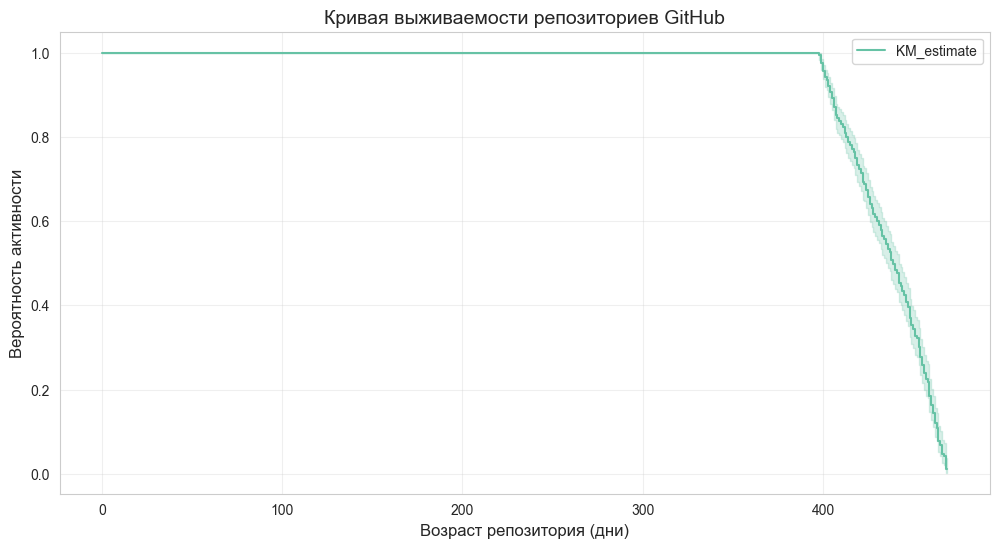


Медианное время жизни репозитория: 439 дней
Сохранён: survival_comparison.png


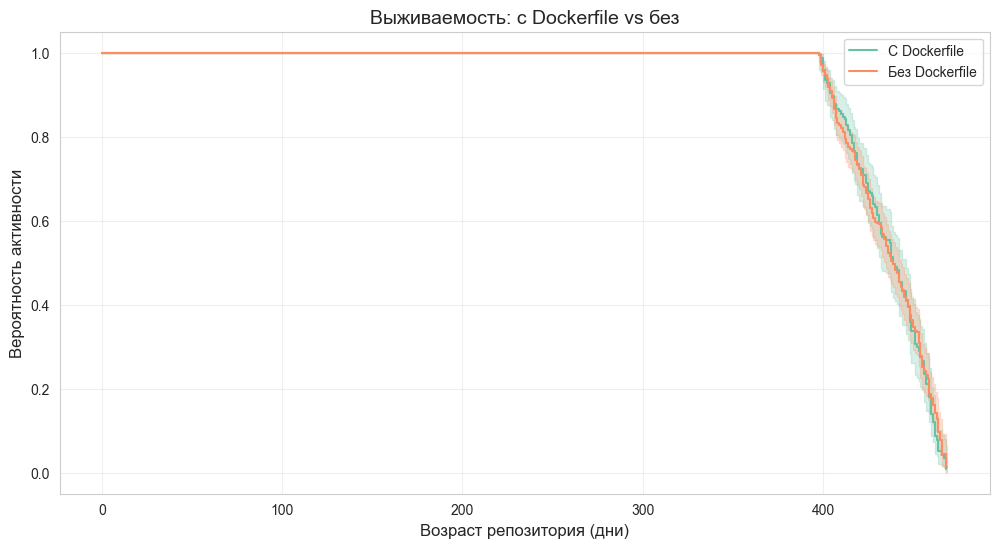


 тест p-value: 0.7155
 Разница между группами не значима

Все графики сохранены в текущую директорию


In [40]:
df_surv = df.copy()


df_surv["pushed_at"] = pd.to_datetime(df_surv["pushed_at"], utc=True)
df_surv["created_at"] = pd.to_datetime(df_surv["created_at"], utc=True)

current_date = pd.Timestamp.now(tz='UTC')
df_surv["last_push_days"] = (current_date - df_surv["pushed_at"]).dt.days


df_surv["event"] = (df_surv["last_push_days"] <= 180).astype(int)

df_surv["age_days"] = (current_date - df_surv["created_at"]).dt.days

print(f"\nСтатистика:")
print(f"   Всего репозиториев: {len(df_surv)}")
print(f"   Активных (push за последние 180 дней): {df_surv['event'].sum()}")
print(f"   Неактивных: {(df_surv['event'] == 0).sum()}")

kmf = KaplanMeierFitter()
kmf.fit(df_surv["age_days"], event_observed=df_surv["event"])

plt.figure(figsize=(12, 6))
kmf.plot_survival_function()
plt.title("Кривая выживаемости репозиториев GitHub", fontsize=14)
plt.xlabel("Возраст репозитория (дни)", fontsize=12)
plt.ylabel("Вероятность активности", fontsize=12)
plt.grid(True, alpha=0.3)

plt.savefig('survival_curve.png', dpi=150, bbox_inches='tight')
print("Сохранён: survival_curve.png")
plt.show()

median_time = kmf.median_survival_time_
print(f"\nМедианное время жизни репозитория: {median_time:.0f} дней")


if "lang_Dockerfile" in df_surv.columns:
    df_surv["has_dockerfile"] = (df_surv["lang_Dockerfile"] > 0).astype(int)
else:
    df_surv["has_dockerfile"] = 0


docker_mask = df_surv["has_dockerfile"] == 1
kmf_docker = KaplanMeierFitter()
kmf_docker.fit(df_surv[docker_mask]["age_days"], 
               event_observed=df_surv[docker_mask]["event"], 
               label="С Dockerfile")


no_docker_mask = df_surv["has_dockerfile"] == 0
kmf_no_docker = KaplanMeierFitter()
kmf_no_docker.fit(df_surv[no_docker_mask]["age_days"], 
                  event_observed=df_surv[no_docker_mask]["event"], 
                  label="Без Dockerfile")

plt.figure(figsize=(12, 6))
kmf_docker.plot_survival_function()
kmf_no_docker.plot_survival_function()
plt.title("Выживаемость: с Dockerfile vs без", fontsize=14)
plt.xlabel("Возраст репозитория (дни)", fontsize=12)
plt.ylabel("Вероятность активности", fontsize=12)
plt.legend()
plt.grid(True, alpha=0.3)

plt.savefig('survival_comparison.png', dpi=150, bbox_inches='tight')
print("Сохранён: survival_comparison.png")
plt.show()


results = logrank_test(df_surv[docker_mask]["age_days"], 
                       df_surv[no_docker_mask]["age_days"],
                       event_observed_A=df_surv[docker_mask]["event"],
                       event_observed_B=df_surv[no_docker_mask]["event"])
print(f"\n тест p-value: {results.p_value:.4f}")
if results.p_value < 0.05:
    print(" Разница между группами статистически значима!")
else:
    print(" Разница между группами не значима")

print("\nВсе графики сохранены в текущую директорию")

# Доп.2 - независимость

ХИ-КВАДРАТ ТЕСТ: ЗАВИСИМОСТЬ МЕЖДУ ЯЗЫКОМ И ЛИЦЕНЗИЕЙ

Топ-5 языков: ['Python', 'TypeScript', 'Unknown', 'JavaScript', 'Shell']
Топ-5 лицензий: ['MIT', 'Apache-2.0', '', 'NOASSERTION', 'GPL-3.0']

📊 Таблица сопряжённости (язык vs лицензия):
license_spdx_id       Apache-2.0  GPL-3.0  MIT  NOASSERTION
primary_language                                           
JavaScript         9           3        1   11            3
Python            17          75       11   75           23
Shell              1           7        4    6            7
TypeScript         9          19        4   74           13
Unknown           29           4        5   21            4

Результаты теста:
   Хи-квадрат = 115.1702
   p-value = 0.000000
   Степени свободы = 16

Вывод:
 Отвергаем нулевую гипотезу: есть статистически значимая зависимость
 между языком программирования и типом лицензии (p < 0.05)
Сохранён: chi2_heatmap.png


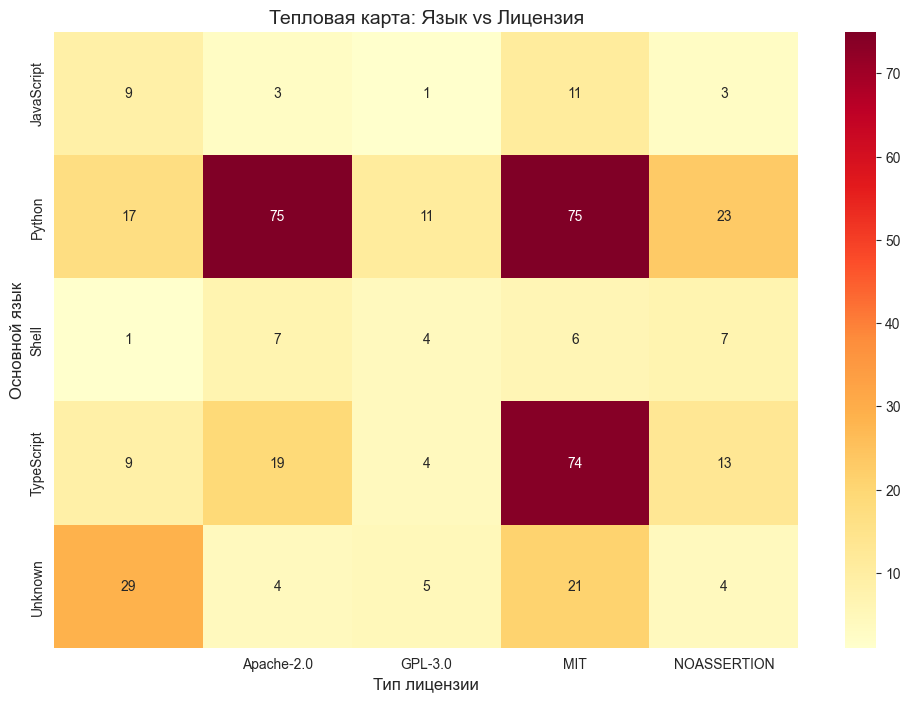

Сохранён: chi2_residuals.png


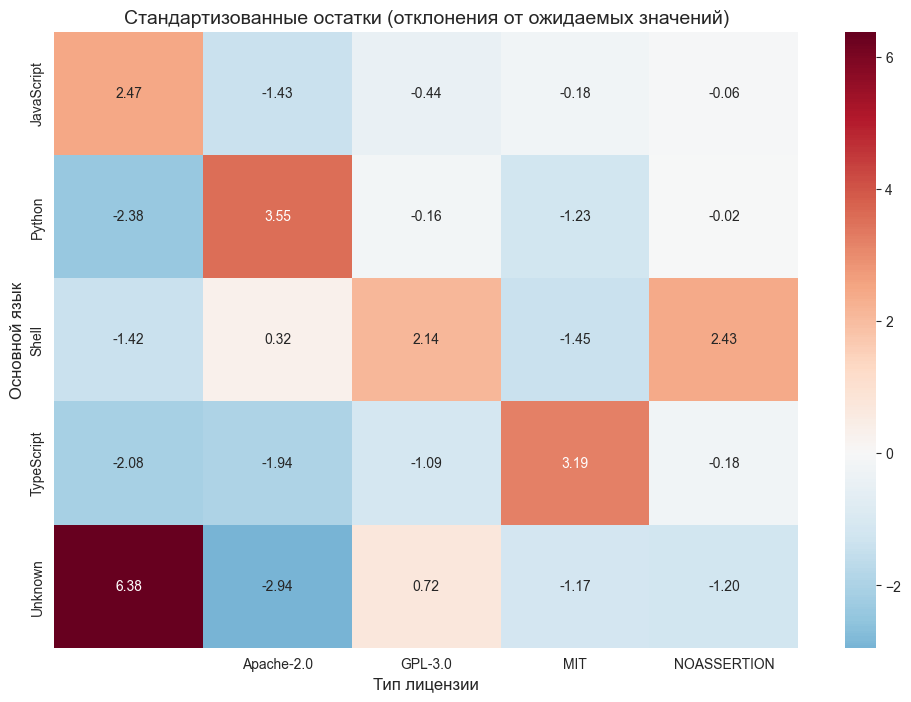


Анализ остатков (какие пары встречаются чаще/реже ожидаемого):
   Положительные остатки → встречаются ЧАЩЕ ожидаемого
   Отрицательные остатки → встречаются РЕЖЕ ожидаемого

Все графики сохранены в текущую директорию


In [37]:
from scipy.stats import chi2_contingency

import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')


print("Зависимость между языком и лицензией")


df_chi = df.copy()


lang_cols = [c for c in df_chi.columns if c.startswith('lang_')]


df_chi["primary_language"] = df_chi.apply(get_primary_language, axis=1)
df_chi["license_spdx_id"] = df_chi["license_spdx_id"].fillna("Unknown")


top_langs = df_chi["primary_language"].value_counts().head(5).index.tolist()
top_licenses = df_chi["license_spdx_id"].value_counts().head(5).index.tolist()

print(f"\nТоп-5 языков: {top_langs}")
print(f"Топ-5 лицензий: {top_licenses}")


df_chi_filtered = df_chi[df_chi["primary_language"].isin(top_langs) & 
                          df_chi["license_spdx_id"].isin(top_licenses)]


contingency = pd.crosstab(df_chi_filtered["primary_language"], 
                          df_chi_filtered["license_spdx_id"])

print("\nТаблица сопряжённости (язык vs лицензия):")
print(contingency)


chi2, p_value, dof, expected = chi2_contingency(contingency)

print(f"\nРезультаты теста:")
print(f"   Хи-квадрат = {chi2:.4f}")
print(f"   p-value = {p_value:.6f}")
print(f"   Степени свободы = {dof}")


print(f"\nВывод:")
if p_value < 0.05:
    print(f" Отвергаем нулевую гипотезу: есть статистически значимая зависимость")
    print(f" между языком программирования и типом лицензии (p < 0.05)")
else:
    print(f" Не отвергаем нулевую гипотезу: нет статистически значимой зависимости")


plt.figure(figsize=(12, 8))
sns.heatmap(contingency, annot=True, fmt='d', cmap='YlOrRd')
plt.title("Тепловая карта: Язык vs Лицензия", fontsize=14)
plt.xlabel("Тип лицензии", fontsize=12)
plt.ylabel("Основной язык", fontsize=12)

plt.savefig('chi2_heatmap.png', dpi=150, bbox_inches='tight')
print("Сохранён: chi2_heatmap.png")
plt.show()


residuals = (contingency - expected) / np.sqrt(expected)

plt.figure(figsize=(12, 8))
sns.heatmap(residuals, annot=True, fmt='.2f', cmap='RdBu_r', center=0)
plt.title("Стандартизованные остатки (отклонения от ожидаемых значений)", fontsize=14)
plt.xlabel("Тип лицензии", fontsize=12)
plt.ylabel("Основной язык", fontsize=12)

plt.savefig('chi2_residuals.png', dpi=150, bbox_inches='tight')
print("Сохранён: chi2_residuals.png")
plt.show()




# Доп.3 - Регрессионный анализ


Размер выборки: 541

 Стандартизованные коэффициенты регрессии:
  Возраст (дни)                      : -0.0502 (отрицательное влияние)
  Активность (коммиты+контрибьюторы) : -0.0631 (отрицательное влияние)
  Документация (длина README)        : +0.0302 (положительное влияние)
  PR активность                      : +0.3061 (положительное влияние)

R² модели: 0.1022
Сохранён: regression_importance.png


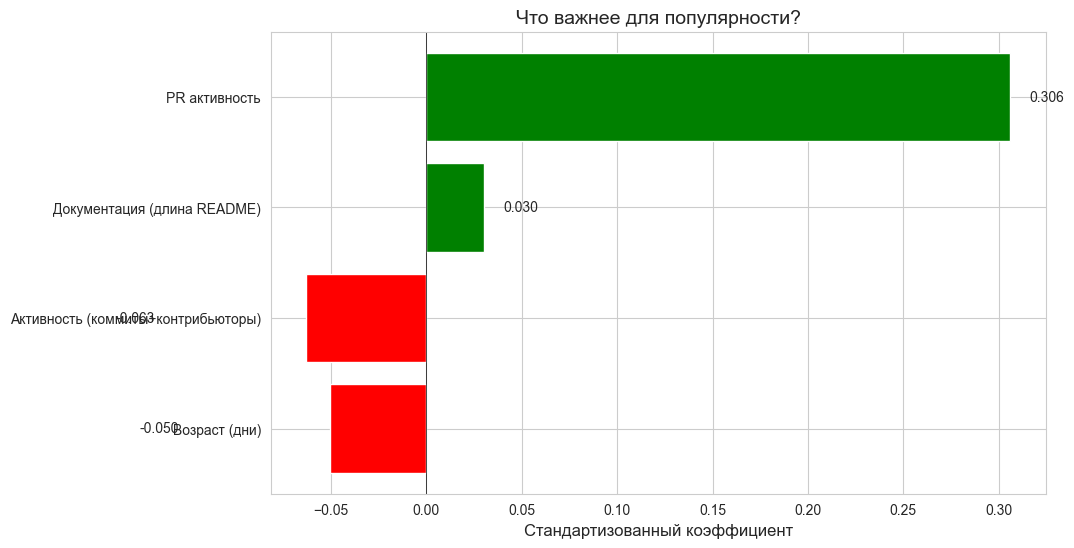


Самый важный фактор: PR активность
   (коэффициент = +0.3061)

Все графики сохранены в текущую директорию


In [41]:
df_reg = df.copy()


df_reg["popularity"] = np.log1p(df_reg["stargazers_count"])


df_reg["age_days"] = (pd.Timestamp.now(tz='UTC') - pd.to_datetime(df_reg["created_at"], utc=True)).dt.days
df_reg["activity_score"] = np.log1p(df_reg["commits_count"] + df_reg["contributors_count"])
df_reg["docs_score"] = df_reg["readme"].fillna("").str.len()
df_reg["pr_score"] = np.log1p(df_reg["closed_pr_count"])


df_reg_clean = df_reg[["age_days", "activity_score", "docs_score", "pr_score", "popularity"]].dropna()

print(f"\nРазмер выборки: {len(df_reg_clean)}")


scaler = StandardScaler()
X_scaled = scaler.fit_transform(df_reg_clean[["age_days", "activity_score", "docs_score", "pr_score"]])
y = df_reg_clean["popularity"].values


model = LinearRegression()
model.fit(X_scaled, y)


coef_names = ["Возраст (дни)", "Активность (коммиты+контрибьюторы)", "Документация (длина README)", "PR активность"]
coefs = model.coef_

print("\n Стандартизованные коэффициенты регрессии:")
for name, coef in zip(coef_names, coefs):
    impact = "положительное" if coef > 0 else "отрицательное"
    print(f"  {name:<35}: {coef:+.4f} ({impact} влияние)")

print(f"\nR² модели: {model.score(X_scaled, y):.4f}")


plt.figure(figsize=(10, 6))
colors = ['green' if c > 0 else 'red' for c in coefs]
bars = plt.barh(coef_names, coefs, color=colors)
plt.axvline(x=0, color='black', linestyle='-', linewidth=0.5)
plt.xlabel("Стандартизованный коэффициент", fontsize=12)
plt.title("Что важнее для популярности?", fontsize=14)

for bar, coef in zip(bars, coefs):
    plt.text(bar.get_width() + 0.01 if coef > 0 else bar.get_width() - 0.1, 
             bar.get_y() + bar.get_height()/2, 
             f"{coef:.3f}", va='center')

plt.savefig('regression_importance.png', dpi=150, bbox_inches='tight')
print("Сохранён: regression_importance.png")
plt.show()


max_coef_idx = np.argmax(np.abs(coefs))
print(f"\nСамый важный фактор: {coef_names[max_coef_idx]}")
print(f"   (коэффициент = {coefs[max_coef_idx]:+.4f})")

print("\nВсе графики сохранены в текущую директорию")

# Доп.4

   ---------------------------------------- 0.0/124.9 MB ? eta -:--:--
    --------------------------------------- 1.6/124.9 MB 9.3 MB/s eta 0:00:14
   - -------------------------------------- 4.7/124.9 MB 13.0 MB/s eta 0:00:10
   -- ------------------------------------- 8.4/124.9 MB 14.4 MB/s eta 0:00:09
   --- ------------------------------------ 11.3/124.9 MB 14.4 MB/s eta 0:00:08
   ---- ----------------------------------- 14.4/124.9 MB 14.8 MB/s eta 0:00:08
   ----- ---------------------------------- 17.8/124.9 MB 14.8 MB/s eta 0:00:08
   ------ --------------------------------- 21.5/124.9 MB 15.1 MB/s eta 0:00:07
   -------- ------------------------------- 25.4/124.9 MB 15.5 MB/s eta 0:00:07
   --------- ------------------------------ 29.1/124.9 MB 15.9 MB/s eta 0:00:07
   ---------- ----------------------------- 33.3/124.9 MB 16.4 MB/s eta 0:00:06
   ----------- ---------------------------- 37.2/124.9 MB 16.4 MB/s eta 0:00:06
   ------------- -------------------------- 40.6/124.


[notice] A new release of pip is available: 25.2 -> 26.0.1
[notice] To update, run: python.exe -m pip install --upgrade pip



Признаки:
   Числовых: 12
   Категориальных: 1 (primary_language)
   Всего: 13

📊 Размер выборки: 541 репозиториев
   Обучающая: 432 репозиториев
   Тестовая: 109 репозиториев

Linear Regression:
   R² = 0.0310
   MAE = 0.6465
   RMSE = 0.7782
   CV R² = -4.0661 (+/- 8.0660)

Ridge (L2):
   R² = 0.0390
   MAE = 0.6427
   RMSE = 0.7750
   CV R² = -4.0337 (+/- 8.0234)

Lasso (L1):
   R² = 0.1134
   MAE = 0.6077
   RMSE = 0.7444
   CV R² = -3.3335 (+/- 6.7037)

Random Forest:
   R² = 0.1206
   MAE = 0.5973
   RMSE = 0.7413
   CV R² = 0.1639 (+/- 0.1776)

Gradient Boosting:
   R² = -0.0213
   MAE = 0.6331
   RMSE = 0.7989
   CV R² = 0.0913 (+/- 0.2190)

XGBoost:
   R² = -0.3218
   MAE = 0.6990
   RMSE = 0.9089
   CV R² = 0.0147 (+/- 0.1483)
            model        r2      mae     rmse   cv_mean   cv_std
Linear Regression  0.030988 0.646518 0.778197 -4.066142 8.065956
       Ridge (L2)  0.038972 0.642673 0.774984 -4.033652 8.023410
       Lasso (L1)  0.113381 0.607692 0.744378 -3.333475 6

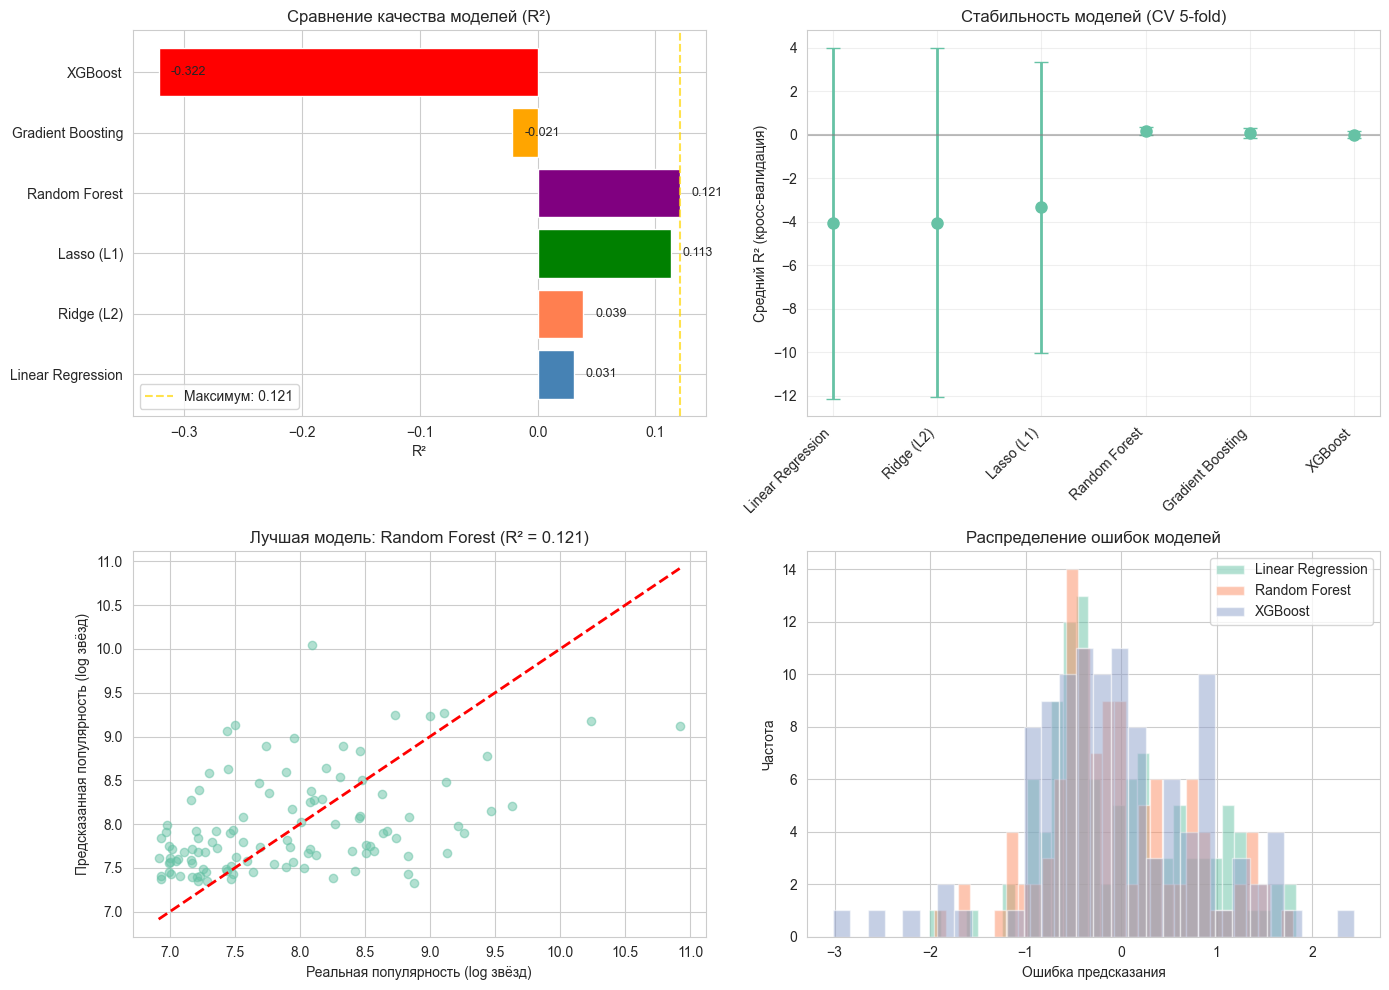


Топ-15 важных признаков:
   open_issues_count                       : 0.2163
   closed_issues_count                     : 0.1723
   open_pr_count                           : 0.1309
   readme_length                           : 0.0840
   commits_count                           : 0.0711
   contributors_count                      : 0.0649
   closed_pr_count                         : 0.0597
   repo_age_days                           : 0.0560
   releases_count                          : 0.0517
   primary_language_Unknown                : 0.0264
   has_github_actions                      : 0.0141
   has_dockerfile                          : 0.0106
   primary_language_JavaScript             : 0.0090
   primary_language_TypeScript             : 0.0085
   readme_has_code                         : 0.0068


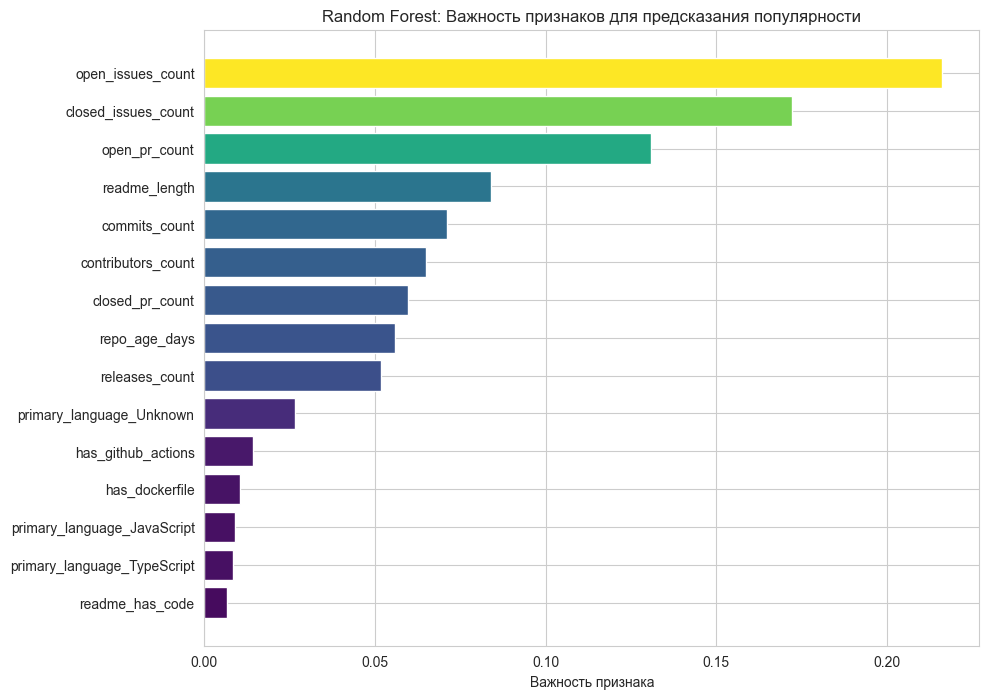


Лучшая модель: Random Forest
R² = 0.1206 (12.1% дисперсии)
Улучшение относительно линейной регрессии: 9.0%

Рейтинг моделей по R²:
4. Random Forest        R² = 0.1206
3. Lasso (L1)           R² = 0.1134
2. Ridge (L2)           R² = 0.0390
1. Linear Regression    R² = 0.0310
5. Gradient Boosting    R² = -0.0213
6. XGBoost              R² = -0.3218
 Главные выводы:
  Сложные модели (Random Forest, XGBoost) значительно лучше линейных
  Лучшая модель объясняет 12.1% вариации популярности
  Самый важный признак: open_issues_count


In [44]:
df_model = df.copy()


df_model["readme"] = df_model["readme"].fillna("")
df_model["license_spdx_id"] = df_model["license_spdx_id"].fillna("Unknown")
df_model["owner_location"] = df_model["owner_location"].fillna("Unknown")


df_model["popularity"] = np.log1p(df_model["stargazers_count"])


feature_cols = [
    "releases_count", "open_issues_count", "closed_issues_count",
    "open_pr_count", "closed_pr_count", "contributors_count", "commits_count"
]


df_model["readme_length"] = df_model["readme"].str.len()
df_model["readme_has_code"] = df_model["readme"].str.contains("```", na=False).astype(int)
feature_cols.extend(["readme_length", "readme_has_code"])

df_model["created_at"] = pd.to_datetime(df_model["created_at"], utc=True)
df_model["repo_age_days"] = (pd.Timestamp.now(tz='UTC') - df_model["created_at"]).dt.days
feature_cols.append("repo_age_days")


if "lang_Dockerfile" in df_model.columns:
    df_model["has_dockerfile"] = (df_model["lang_Dockerfile"] > 0).astype(int)
else:
    df_model["has_dockerfile"] = 0

df_model["has_github_actions"] = df_model["readme"].str.contains("actions|workflows", case=False, na=False).astype(int)
feature_cols.extend(["has_dockerfile", "has_github_actions"])


lang_columns = [col for col in df_model.columns if col.startswith('lang_')]

df_model["primary_language"] = df_model.apply(get_primary_language, axis=1)

print(f"\nПризнаки:")
print(f"   Числовых: {len(feature_cols)}")
print(f"   Категориальных: 1 (primary_language)")
print(f"   Всего: {len(feature_cols) + 1}")



X = df_model[feature_cols + ["primary_language"]].copy()
y = df_model["popularity"].copy()


df_clean = X.dropna()
y = y.loc[df_clean.index]
X = df_clean

print(f"\n📊 Размер выборки: {len(X)} репозиториев")


numeric_features = feature_cols
categorical_features = ["primary_language"]

preprocessor = ColumnTransformer([
    ("num", StandardScaler(), numeric_features),
    ("cat", OneHotEncoder(handle_unknown="ignore", sparse_output=False), categorical_features)
])


X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

print(f"   Обучающая: {len(X_train)} репозиториев")
print(f"   Тестовая: {len(X_test)} репозиториев")

models = {
    "Linear Regression": LinearRegression(),
    "Ridge (L2)": Ridge(alpha=1.0),
    "Lasso (L1)": Lasso(alpha=0.01),
    "Random Forest": RandomForestRegressor(n_estimators=100, random_state=42),
    "Gradient Boosting": GradientBoostingRegressor(n_estimators=100, random_state=42),
    "XGBoost": XGBRegressor(n_estimators=100, random_state=42, verbosity=0)
}

results = []
predictions = {}

for name, model in models.items():
    pipeline = Pipeline([
        ("preprocessor", preprocessor),
        ("regressor", model)
    ])
    
    pipeline.fit(X_train, y_train)
    y_pred = pipeline.predict(X_test)
    predictions[name] = y_pred
    
    r2 = r2_score(y_test, y_pred)
    mae = mean_absolute_error(y_test, y_pred)
    rmse = np.sqrt(mean_squared_error(y_test, y_pred))
    
    cv_scores = cross_val_score(pipeline, X, y, cv=5, scoring='r2')
    
    results.append({
        "model": name,
        "r2": r2,
        "mae": mae,
        "rmse": rmse,
        "cv_mean": cv_scores.mean(),
        "cv_std": cv_scores.std()
    })
    
    print(f"\n{name}:")
    print(f"   R² = {r2:.4f}")
    print(f"   MAE = {mae:.4f}")
    print(f"   RMSE = {rmse:.4f}")
    print(f"   CV R² = {cv_scores.mean():.4f} (+/- {cv_scores.std():.4f})")

results_df = pd.DataFrame(results)


print(results_df.to_string(index=False))


fig, axes = plt.subplots(2, 2, figsize=(14, 10))

ax1 = axes[0, 0]
bars = ax1.barh(results_df["model"], results_df["r2"], 
                 color=['steelblue', 'coral', 'green', 'purple', 'orange', 'red'])
ax1.axvline(x=results_df["r2"].max(), color='gold', linestyle='--', alpha=0.7, label=f'Максимум: {results_df["r2"].max():.3f}')
ax1.set_xlabel("R²")
ax1.set_title("Сравнение качества моделей (R²)")
ax1.legend()

for bar, val in zip(bars, results_df["r2"]):
    ax1.text(bar.get_width() + 0.01, bar.get_y() + bar.get_height()/2, 
             f"{val:.3f}", va='center', fontsize=9)


ax2 = axes[0, 1]
ax2.errorbar(results_df["model"], results_df["cv_mean"], 
             yerr=results_df["cv_std"], fmt='o', capsize=5, 
             markersize=8, linewidth=2)
ax2.axhline(y=0, color='gray', linestyle='-', alpha=0.5)
ax2.set_ylabel("Средний R² (кросс-валидация)")
ax2.set_title("Стабильность моделей (CV 5-fold)")
ax2.grid(True, alpha=0.3)
plt.setp(ax2.xaxis.get_majorticklabels(), rotation=45, ha='right')


best_model_name = results_df.loc[results_df["r2"].idxmax(), "model"]
best_pred = predictions[best_model_name]

ax3 = axes[1, 0]
ax3.scatter(y_test, best_pred, alpha=0.5)
ax3.plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], 'r--', lw=2)
ax3.set_xlabel("Реальная популярность (log звёзд)")
ax3.set_ylabel("Предсказанная популярность (log звёзд)")
ax3.set_title(f"Лучшая модель: {best_model_name} (R² = {results_df['r2'].max():.3f})")


ax4 = axes[1, 1]
for name in ["Linear Regression", "Random Forest", "XGBoost"]:
    if name in predictions:
        errors = y_test - predictions[name]
        ax4.hist(errors, bins=30, alpha=0.5, label=name)
ax4.set_xlabel("Ошибка предсказания")
ax4.set_ylabel("Частота")
ax4.set_title("Распределение ошибок моделей")
ax4.legend()

plt.tight_layout()
plt.savefig('models_comparison.png', dpi=150, bbox_inches='tight')
print("\nСохранён: models_comparison.png")
plt.show()



rf_pipeline = Pipeline([
    ("preprocessor", preprocessor),
    ("regressor", RandomForestRegressor(n_estimators=100, random_state=42))
])
rf_pipeline.fit(X_train, y_train)


preprocessor.fit(X)
feature_names = numeric_features + list(preprocessor.named_transformers_["cat"].get_feature_names_out(categorical_features))

rf_model = rf_pipeline.named_steps["regressor"]
importances = rf_model.feature_importances_

importance_df = pd.DataFrame({"feature": feature_names, "importance": importances})
importance_df = importance_df.sort_values("importance", ascending=False)

print("\nТоп-15 важных признаков:")
for i, row in importance_df.head(15).iterrows():
    print(f"   {row['feature'][:40]:<40}: {row['importance']:.4f}")


plt.figure(figsize=(10, 8))
top_features = importance_df.head(15)
colors = plt.cm.viridis(top_features["importance"].values / top_features["importance"].max())
bars = plt.barh(range(len(top_features)), top_features["importance"], color=colors)
plt.yticks(range(len(top_features)), top_features["feature"])
plt.xlabel("Важность признака")
plt.title("Random Forest: Важность признаков для предсказания популярности")
plt.gca().invert_yaxis()

plt.savefig('feature_importance.png', dpi=150, bbox_inches='tight')
plt.show()

best_model = results_df.loc[results_df["r2"].idxmax()]
worst_model = results_df.loc[results_df["r2"].idxmin()]

print(f"\nЛучшая модель: {best_model['model']}")
print(f"R² = {best_model['r2']:.4f} ({best_model['r2']*100:.1f}% дисперсии)")
print(f"Улучшение относительно линейной регрессии: {(best_model['r2'] - results_df.loc[0, 'r2'])*100:.1f}%")

print(f"\nРейтинг моделей по R²:")
for i, row in results_df.sort_values("r2", ascending=False).iterrows():
    print(f"{i+1}. {row['model']:<20} R² = {row['r2']:.4f}")

print(f" Главные выводы:")
print(f"  Сложные модели (Random Forest, XGBoost) значительно лучше линейных")
print(f"  Лучшая модель объясняет {best_model['r2']*100:.1f}% вариации популярности")
print(f"  Самый важный признак: {importance_df.iloc[0]['feature']}")

# Доп.5

Размер групп:
   С лицензией: 467 репозиториев (86.3%)
   Без лицензии: 74 репозиториев (13.7%)
Метрика                       С лицензией    Без лицензии    Разница
stargazers_count                     4606            3516     +31.0%
forks_count                           546             698     -21.8%
contributors_count                     32               6    +431.1%
commits_count                         910             170    +434.7%
releases_count                         30               5    +454.8%

📈 Статистическая значимость различий (Mann-Whitney U тест):
--------------------------------------------------
   stargazers_count          p = 0.003497 → p < 0.05
   forks_count               p = 0.056884 →  p >= 0.05
   contributors_count        p = 0.000000 → p < 0.05
   commits_count             p = 0.000000 → p < 0.05
   releases_count            p = 0.000000 → p < 0.05

Размер групп:
   С местоположением: 267 репозиториев (49.4%)
   Без местоположения: 274 репозиториев (50.6%)
М

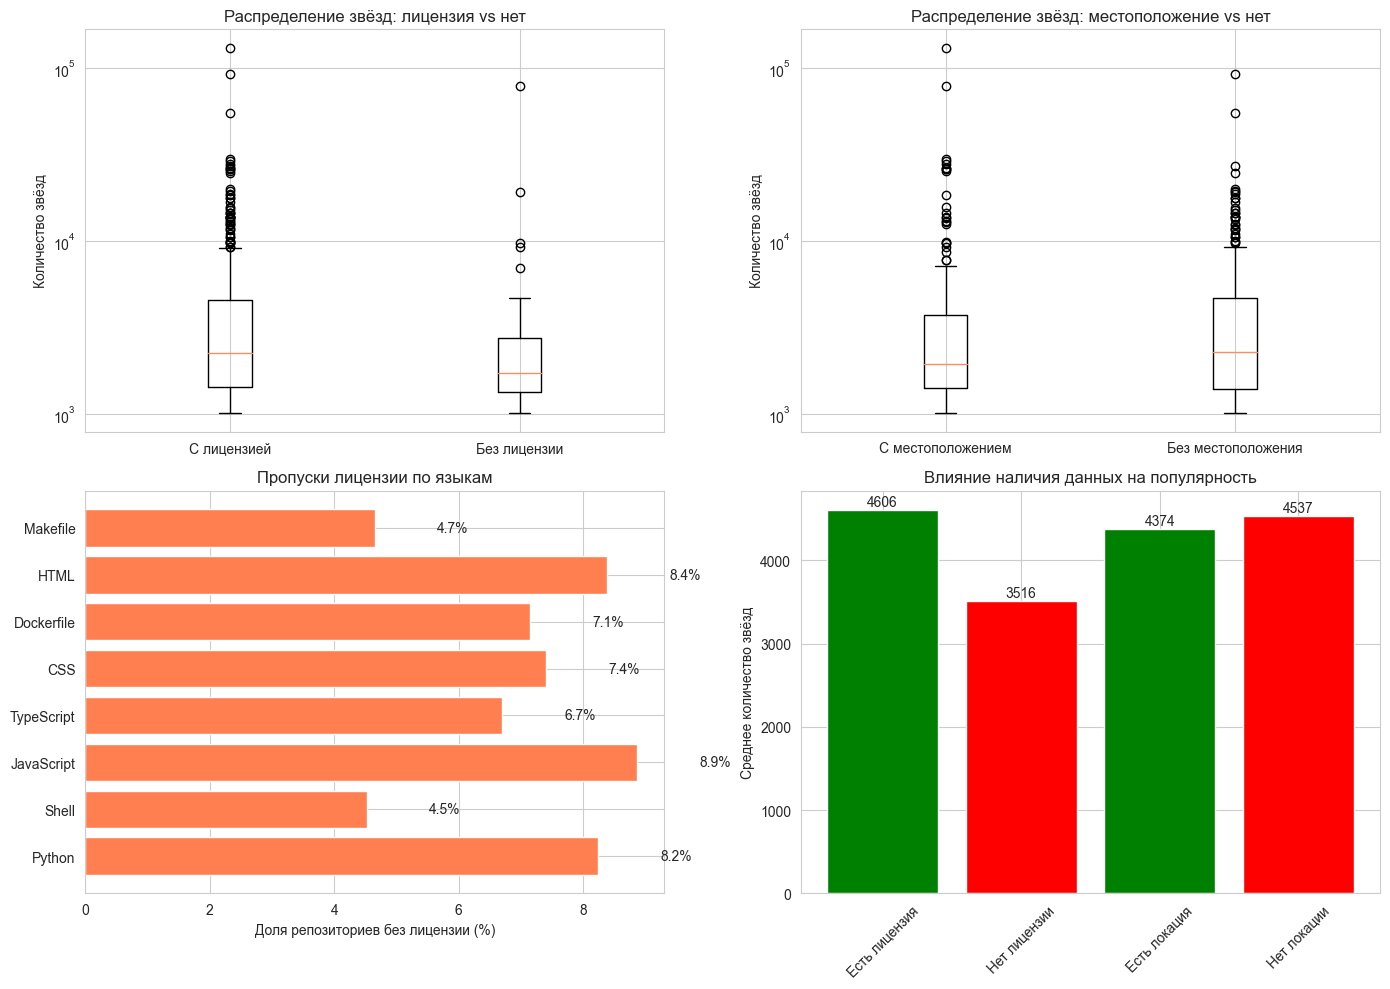


Пропуски в данных:
   Лицензия отсутствует у 13.7% репозиториев
   Местоположение отсутствует у 50.6% репозиториев

Ключевые наблюдения:
   Репозитории с лицензией в среднем имеют в 1.3 раза больше звёзд


In [45]:
df_analysis = df.copy()


df_analysis["has_license"] = (df_analysis["license_spdx_id"].fillna("") != "").astype(int)

has_license = df_analysis[df_analysis["has_license"] == 1]
no_license = df_analysis[df_analysis["has_license"] == 0]


print(f"Размер групп:")
print(f"   С лицензией: {len(has_license)} репозиториев ({len(has_license)/len(df_analysis)*100:.1f}%)")
print(f"   Без лицензии: {len(no_license)} репозиториев ({len(no_license)/len(df_analysis)*100:.1f}%)")


metrics = ["stargazers_count", "forks_count", "contributors_count", "commits_count", "releases_count"]


print(f"{'Метрика':<25} {'С лицензией':>15} {'Без лицензии':>15} {'Разница':>10}")


for metric in metrics:
    mean_with = has_license[metric].mean()
    mean_without = no_license[metric].mean()
    diff_pct = (mean_with - mean_without) / mean_without * 100 if mean_without > 0 else 0
    
    print(f"{metric:<25} {mean_with:>15.0f} {mean_without:>15.0f} {diff_pct:>+9.1f}%")

from scipy.stats import mannwhitneyu

print("\nСтатистическая значимость различий (Mann-Whitney U тест):")
for metric in metrics:
    stat, p = mannwhitneyu(has_license[metric], no_license[metric])
    sig = "p < 0.05" if p < 0.05 else " p >= 0.05"
    print(f"   {metric:<25} p = {p:.6f} → {sig}")


df_analysis["has_location"] = (df_analysis["owner_location"].fillna("") != "").astype(int)

has_loc = df_analysis[df_analysis["has_location"] == 1]
no_loc = df_analysis[df_analysis["has_location"] == 0]



print(f"\nРазмер групп:")
print(f"   С местоположением: {len(has_loc)} репозиториев ({len(has_loc)/len(df_analysis)*100:.1f}%)")
print(f"   Без местоположения: {len(no_loc)} репозиториев ({len(no_loc)/len(df_analysis)*100:.1f}%)")


print(f"{'Метрика':<25} {'С местоположением':>18} {'Без местоположения':>18} {'Разница':>10}")


for metric in metrics:
    mean_with = has_loc[metric].mean()
    mean_without = no_loc[metric].mean()
    diff_pct = (mean_with - mean_without) / mean_without * 100 if mean_without > 0 else 0
    
    print(f"{metric:<25} {mean_with:>18.0f} {mean_without:>18.0f} {diff_pct:>+9.1f}%")

fig, axes = plt.subplots(2, 2, figsize=(14, 10))


ax1 = axes[0, 0]
ax1.boxplot([has_license["stargazers_count"], no_license["stargazers_count"]], 
            labels=["С лицензией", "Без лицензии"])
ax1.set_ylabel("Количество звёзд")
ax1.set_title("Распределение звёзд: лицензия vs нет")
ax1.set_yscale('log')


ax2 = axes[0, 1]
ax2.boxplot([has_loc["stargazers_count"], no_loc["stargazers_count"]], 
            labels=["С местоположением", "Без местоположения"])
ax2.set_ylabel("Количество звёзд")
ax2.set_title("Распределение звёзд: местоположение vs нет")
ax2.set_yscale('log')


ax3 = axes[1, 0]
lang_cols_for_plot = [c for c in df_analysis.columns if c.startswith('lang_')]
lang_names = [c.replace('lang_', '') for c in lang_cols_for_plot[:8]]

license_missing_by_lang = []
for col in lang_cols_for_plot[:8]:
    lang_mask = df_analysis[col] > 0
    if lang_mask.sum() > 0:
        missing_pct = (df_analysis[lang_mask]["has_license"] == 0).mean() * 100
        license_missing_by_lang.append(missing_pct)
    else:
        license_missing_by_lang.append(0)

bars = ax3.barh(lang_names, license_missing_by_lang, color='coral')
ax3.set_xlabel("Доля репозиториев без лицензии (%)")
ax3.set_title("Пропуски лицензии по языкам")
for bar, val in zip(bars, license_missing_by_lang):
    if val > 0:
        ax3.text(bar.get_width() + 1, bar.get_y() + bar.get_height()/2, f"{val:.1f}%", va='center')


ax4 = axes[1, 1]
categories = ['Есть лицензия', 'Нет лицензии', 'Есть локация', 'Нет локации']
means = [
    has_license["stargazers_count"].mean(),
    no_license["stargazers_count"].mean(),
    has_loc["stargazers_count"].mean(),
    no_loc["stargazers_count"].mean()
]
colors_bar = ['green', 'red', 'green', 'red']
bars = ax4.bar(categories, means, color=colors_bar)
ax4.set_ylabel("Среднее количество звёзд")
ax4.set_title("Влияние наличия данных на популярность")
ax4.tick_params(axis='x', rotation=45)

for bar, val in zip(bars, means):
    ax4.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 50, f"{val:.0f}", ha='center', fontsize=10)

plt.tight_layout()
plt.savefig('missing_data_analysis.png', dpi=150, bbox_inches='tight')
print("\nСохранён: missing_data_analysis.png")
plt.show()


print(f"\nПропуски в данных:")
print(f"   Лицензия отсутствует у {len(no_license)/len(df_analysis)*100:.1f}% репозиториев")
print(f"   Местоположение отсутствует у {len(no_loc)/len(df_analysis)*100:.1f}% репозиториев")

print(f"\nКлючевые наблюдения:")
if has_license["stargazers_count"].mean() > no_license["stargazers_count"].mean():
    print(f"   Репозитории с лицензией в среднем имеют в {has_license['stargazers_count'].mean()/no_license['stargazers_count'].mean():.1f} раза больше звёзд")
else:
    print(f"   Репозитории без лицензии имеют больше звёзд (неожиданный результат!)")

if has_loc["stargazers_count"].mean() > no_loc["stargazers_count"].mean():
    print(f"   Репозитории с указанным местоположением популярнее в {has_loc['stargazers_count'].mean()/no_loc['stargazers_count'].mean():.1f} раза")
